# import Libary

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')


1. Pengaturan Tampilan

In [2]:
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'

print("=" * 55)
print("  ANALISIS CLUSTERING DATA PENJUALAN JAN–MAR")
print("=" * 55)
print("✅ Semua library berhasil diimport")


  ANALISIS CLUSTERING DATA PENJUALAN JAN–MAR
✅ Semua library berhasil diimport


# Load Data

1. Fungsi Pembaca File

In [3]:
def baca_csv(filepath, bulan):
    df = pd.read_csv(filepath, sep=';', on_bad_lines='skip')
    df = df[df['SKU'].astype(str).str.match(r'^\d', na=False)].copy()
    df['Bulan'] = bulan
    return df

def baca_xlsx(filepath, bulan):
    df = pd.read_excel(filepath, dtype=str) # Load all rows first
    df['Bulan'] = bulan # Add bulan early

    # Attempt to convert Qty and Harga Satuan to numeric, coercing errors to NaN
    df['Qty_numeric_temp'] = pd.to_numeric(df['Qty'], errors='coerce')
    df['HargaSatuan_numeric_temp'] = pd.to_numeric(df['Harga Satuan'], errors='coerce')

    # Identify potential category rows: where Qty and Harga Satuan are NaN
    # and SKU has a value (assuming SKU holds the category name in such rows)
    category_mask = df['Qty_numeric_temp'].isna() & df['HargaSatuan_numeric_temp'].isna() & df['SKU'].notna()

    df['Kategori'] = np.nan # Initialize Kategori column with NaN
    # Assign SKU as category for identified category rows
    df.loc[category_mask, 'Kategori'] = df.loc[category_mask, 'SKU']

    df['Kategori'] = df['Kategori'].ffill() # Forward fill categories to product rows

    # Now filter for actual product rows (SKU starts with a digit)
    df = df[df['SKU'].astype(str).str.match(r'^\d', na=False)].copy()

    # Clean up temporary columns
    df.drop(columns=['Qty_numeric_temp', 'HargaSatuan_numeric_temp'], inplace=True, errors='ignore')

    return df

2. Load 3 File (Bulan Januari, Februari, Maret)

In [4]:
df_jan = baca_xlsx("/content/drive/MyDrive/BISMILLAH KP/Ringkasan Penjualan Produk - Januari.xlsx", 'Januari')
df_feb = baca_xlsx("/content/drive/MyDrive/BISMILLAH KP/Ringkasan Penjualan Produk - Februari.xlsx", 'Februari')
df_mar = baca_xlsx("/content/drive/MyDrive/BISMILLAH KP/Ringkasan Penjualan Produk - Maret.xlsx", 'Maret')

3. Penggabungan ke 3 data menjadi 1 DataFrame Mentah

In [5]:
# Gabungkan ke satu DataFrame mentah
df_raw = pd.concat([df_jan, df_feb, df_mar], ignore_index=True)

print(f"\n📂 File berhasil dibaca:")
print(f"   Januari  : {len(df_jan):>4} baris produk")
print(f"   Februari : {len(df_feb):>4} baris produk")
print(f"   Maret    : {len(df_mar):>4} baris produk")
print(f"   {'─'*30}")
print(f"   Total    : {len(df_raw):>4} baris (sebelum cleaning)")

print("\n📋 Kolom yang tersedia:")
print("   ", df_raw.columns.tolist())

print("\n📋 Pratinjau 5 baris pertama data mentah:")
print(df_raw[['Produk','Qty','Harga Satuan']].head())


📂 File berhasil dibaca:
   Januari  :  123 baris produk
   Februari :  130 baris produk
   Maret    :  134 baris produk
   ──────────────────────────────
   Total    :  387 baris (sebelum cleaning)

📋 Kolom yang tersedia:
    ['SKU', 'Produk', 'Qty', 'Harga Satuan', 'Diskon', 'Harga Jual Setelah Diskon', 'Harga rata rata', 'Cogs', 'Gross Profit', 'Gross Profit %', '% Penjualan', 'Metode Pembayaran', 'Bulan', 'Kategori']

📋 Pratinjau 5 baris pertama data mentah:
             Produk Qty Harga Satuan
0       Melon Varde  11       187000
1       Fruit Punch   3        72000
2       Mango LIght  26       494000
3  Strawberry Heart  17       323000
4     Dragon Purple  11       187000


# Data Cleaning

In [6]:
print("\n" + "=" * 55)
print("  DATA CLEANING")
print("=" * 55)

df = df_raw.copy()


  DATA CLEANING


1. Konversi tipe data numerik

In [7]:
kolom_numerik = ['Qty', 'Harga Satuan', 'Diskon',
                 'Harga Jual Setelah Diskon', 'Cogs', 'Gross Profit']
for kol in kolom_numerik:
    if kol in df.columns:
        df[kol] = pd.to_numeric(df[kol], errors='coerce')

print(f"✅ Konversi numerik selesai pada {len(kolom_numerik)} kolom")

✅ Konversi numerik selesai pada 6 kolom


2. Cek Missing Value Sebelum Cleaning

In [8]:
print("\n🔍 Missing value per kolom (sebelum cleaning):")
mv = df[['SKU','Produk','Qty','Harga Satuan']].isnull().sum()
for k, v in mv.items():
    status = "⚠️  ADA" if v > 0 else "✅ Bersih"
    print(f"   {k:<25}: {v:>4} missing  {status}")


🔍 Missing value per kolom (sebelum cleaning):
   SKU                      :    0 missing  ✅ Bersih
   Produk                   :    0 missing  ✅ Bersih
   Qty                      :    0 missing  ✅ Bersih
   Harga Satuan             :    0 missing  ✅ Bersih


3. Hapus baris yang tidak lengkap

In [9]:
n_sebelum = len(df)
df = df.dropna(subset=['Produk', 'Qty', 'Harga Satuan'])
df = df[df['Qty'] > 0]
df = df[df['Harga Satuan'] > 0]
n_sesudah = len(df)
print(f"\n✅ Baris dihapus karena data tidak lengkap: {n_sebelum - n_sesudah}")
print(f"✅ Baris tersisa: {n_sesudah}")


✅ Baris dihapus karena data tidak lengkap: 4
✅ Baris tersisa: 383


4. Hitung Harga Per Item



In [10]:
# Harga Satuan di file = total revenue produk tersebut per bulan
# Harga unit = total revenue / qty
df['Harga_Unit'] = (df['Harga Satuan'] / df['Qty']).round(0)

5. Isi nilai kosong kolom non kritis

In [11]:
df['Diskon'] = df['Diskon'].fillna(0)
if 'Gross Profit' in df.columns:
    df['Gross Profit'] = df['Gross Profit'].fillna(0)

6. Menghapus Kategori Spesial Ramadhan. Additinal karena akan menjadikan bias dalam data saat melalkukan processing

In [12]:
# Produk/kategori berikut dikeluarkan dari analisis karena
# bersifat musiman, event, atau utilitas pelengkap —
# sehingga tidak mencerminkan pilihan aktif pelanggan harian.

print("=" * 55)
print("  EKSKLUSIF PRODUK & KATEGORI")
print("=" * 55)

# ── A. Kategori yang seluruhnya dikeluarkan ────────────────
EXCL_KATEGORI = [
    'SPECIAL RAMADHAN',           # Paket musiman Ramadhan
    "VALENTINE'S SPECIAL PACKAGE",# Event Valentine
    'VALENTINE PACKAGE',          # Event Valentine (varian nama)
    'Paket Event',                # Event non-reguler
    'FREE [Deleted]',             # Produk dihapus / gratisan
    'Special Bundling [Deleted]', # Bundling dihapus
]

# ── B. Produk spesifik dalam kategori 'Additional' ────────
# Mineral, Ice Cube, Nasi Putih = utilitas wajib/pelengkap,
# bukan pilihan menu aktif pelanggan.
EXCL_PRODUK = [
    'Mineral',
    'Ice Cube',
    'Nasi Putih',
]

# ── Terapkan filter ──────────────────────────────────────

# Apply masks to the already cleaned 'df'
mask_kategori = df['Kategori'].isin(EXCL_KATEGORI)
mask_produk   = df['Produk'].isin(EXCL_PRODUK)
mask_eksklusif = mask_kategori | mask_produk

# Create df_filtered from the cleaned df
df_filtered = df[~mask_eksklusif].copy()

# Laporan eksklusif
excl_df = df[mask_eksklusif].copy() # excl_df also from cleaned df

print(f"\n📋 Ringkasan yang dikeluarkan dari analisis:")
print(f"   Total baris sebelum filter : {len(df):>4}") # <--- now uses df
print(f"   Baris dikeluarkan          : {len(excl_df):>4}")
print(f"   Baris untuk analisis       : {len(df_filtered):>4}")

print(f"\n   Detail per alasan eksklusif:")
print(f"   {'Kategori/Produk':<35} {'Jumlah Baris':>12} {'Total Qty':>10}")
print(f"   {'─'*57}")

# Kategori
for kat in EXCL_KATEGORI:
    subset = excl_df[excl_df['Kategori'] == kat]
    if len(subset) > 0:
        total_qty = subset['Qty'].sum() # Qty is already numeric in df/excl_df
        print(f"   [KATEGORI] {kat:<24} {len(subset):>12} {int(total_qty):>10}")

# Produk individual
for prod in EXCL_PRODUK:
    subset = excl_df[excl_df['Produk'] == prod]
    if len(subset) > 0:
        total_qty = subset['Qty'].sum() # Qty is already numeric in df/excl_df
        print(f"   [PRODUK]   {prod:<24} {len(subset):>12} {int(total_qty):>10}")

print(f"\n✅ df_filtered siap — {len(df_filtered)} baris akan masuk ke analisis")
print(f"   Variabel berikutnya menggunakan: df_filtered (bukan df_raw)")

  EKSKLUSIF PRODUK & KATEGORI

📋 Ringkasan yang dikeluarkan dari analisis:
   Total baris sebelum filter :  383
   Baris dikeluarkan          :   26
   Baris untuk analisis       :  357

   Detail per alasan eksklusif:
   Kategori/Produk                     Jumlah Baris  Total Qty
   ─────────────────────────────────────────────────────────
   [KATEGORI] SPECIAL RAMADHAN                   11       2979
   [KATEGORI] VALENTINE'S SPECIAL PACKAGE            2          4
   [KATEGORI] VALENTINE PACKAGE                   1          1
   [KATEGORI] Paket Event                         1         10
   [KATEGORI] Special Bundling [Deleted]            2          5
   [PRODUK]   Mineral                             3        947
   [PRODUK]   Ice Cube                            3         69
   [PRODUK]   Nasi Putih                          3         38

✅ df_filtered siap — 357 baris akan masuk ke analisis
   Variabel berikutnya menggunakan: df_filtered (bukan df_raw)


In [13]:
print("\n📊 Statistik Deskriptif df_filtered:")
display(df_filtered.describe())


📊 Statistik Deskriptif df_filtered:


,Qty,Harga Satuan,Diskon,Harga Jual Setelah Diskon,Cogs,Gross Profit,Harga_Unit
count,357.00,357.00,357.00,357.00,357.00,357.00,357.00
mean,23.31,"528,453.78","8,083.75","520,370.03","70,084.22","450,285.81","22,970.69"
std,28.38,"622,971.78","10,659.87","616,626.75","132,200.94","535,164.88","5,899.59"
min,1.00,"7,000.00",0.00,"7,000.00",0.00,"7,000.00","5,000.00"
25%,6.00,"144,000.00",0.00,"140,000.00",0.00,"125,000.00","20,000.00"
50%,13.00,"330,000.00","4,050.00","325,000.00",0.00,"275,000.00","24,000.00"
75%,30.00,"675,000.00","12,600.00","653,400.00","95,840.18","601,559.70","26,000.00"
max,265.00,"5,830,000.00","56,700.00","5,788,200.00","1,028,745.90","4,759,454.10","40,000.00"


In [14]:
df_filtered

,SKU,Produk,Qty,Harga Satuan,Diskon,Harga Jual Setelah Diskon,Harga rata rata,Cogs,Gross Profit,Gross Profit %,% Penjualan,Metode Pembayaran,Bulan,Kategori,Harga_Unit
0,000403,Melon Varde,11,187000,"8,500.00","178,500.00",16227.27,0.00,"178,500.00",100.00 %,NaN,"Cash, QRIS BCA, Qris BTN, QRIS BRI",Januari,Juice,"17,000.00"
1,000405,Fruit Punch,3,72000,0.00,"72,000.00",24000,0.00,"72,000.00",100.00 %,NaN,"Qris BTN, QRIS BRI",Januari,Juice,"24,000.00"
2,000402,Mango LIght,26,494000,"5,700.00","488,300.00",18780.77,0.00,"488,300.00",100.00 %,NaN,"Cash, Qris BTN, QRIS BRI",Januari,Juice,"19,000.00"
3,000401,Strawberry Heart,17,323000,"2,850.00","320,150.00",18832.35,0.00,"320,150.00",100.00 %,NaN,"Cash, Qris BTN, QRIS BRI, QRIS BCA",Januari,Juice,"19,000.00"
4,000404,Dragon Purple,11,187000,0.00,"187,000.00",17000,0.00,"187,000.00",100.00 %,NaN,"Qris BTN, Cash",Januari,Juice,"17,000.00"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
382,000064,Nasi Goreng Jawa,46,1150000,"3,750.00","1,146,250.00",24918.48,"367,032.66","779,217.34",67.98 %,NaN,"QRIS BCA, Cash, Debit Card",Maret,Special Nusantara,"25,000.00"
383,000062,Nasi Goreng Tomyum,7,189000,"9,450.00","179,550.00",25650,"64,528.60","115,021.40",64.06 %,NaN,"QRIS BCA, Debit Card, Cash",Maret,Special Nusantara,"27,000.00"
384,000028,Tubruk,11,165000,0.00,"165,000.00",15000,"27,544.00","137,456.00",83.31 %,NaN,"Debit Card, QRIS BCA, Cash",Maret,Manual Brew,"15,000.00"
385,000289,V60 Guest Beans Ice,14,378000,0.00,"378,000.00",27000,"130,064.50","247,935.50",65.59 %,NaN,"Cash, QRIS BCA",Maret,Manual Brew,"27,000.00"


7. Hapus duplikasi SKU yang sama dalam bulan yang sama

In [15]:

n_before_dedup = len(df_filtered)
df_filtered = df_filtered.drop_duplicates(subset=['SKU','Bulan'], keep='first')
n_after_dedup = len(df_filtered)
duplicates_removed = n_before_dedup - n_after_dedup

print(f"✅ Duplikasi dihapus: {duplicates_removed} baris")

print("\n📋 Contoh data setelah cleaning:")
print(df_filtered[['SKU','Produk','Qty','Harga_Unit','Bulan']].head(357).to_string(index=False))

✅ Duplikasi dihapus: 0 baris

📋 Contoh data setelah cleaning:
   SKU                             Produk  Qty  Harga_Unit    Bulan
000403                        Melon Varde   11   17,000.00  Januari
000405                        Fruit Punch    3   24,000.00  Januari
000402                        Mango LIght   26   19,000.00  Januari
000401                   Strawberry Heart   17   19,000.00  Januari
000404                      Dragon Purple   11   17,000.00  Januari
000079                       Chicken Skin    8   18,000.00  Januari
000075               Korean Chicken Wings    7   22,000.00  Januari
000351                    Tahu Cabe Garam   18   20,000.00  Januari
000084                    Mushroom Crispy    9   18,000.00  Januari
000350                    Bolognese Fries    7   20,000.00  Januari
000087                    Banana Fritters   36   18,000.00  Januari
000086                       Banana Katsu   15   18,000.00  Januari
000077                 Sambel Matah Fries    5   18,00

# Data Processing

In [16]:
print("\n" + "=" * 55)
print("  DATA PROCESSING – AGREGASI 3 BULAN")
print("=" * 55)


  DATA PROCESSING – AGREGASI 3 BULAN


1. Agregasi per produk (SKU) gabungan 3 bulan

In [17]:
bulan_order = ['Januari', 'Februari', 'Maret']

def qty_bulan(grp, bulan):
    val = grp.loc[grp['Bulan'] == bulan, 'Qty']
    return val.sum() if len(val) > 0 else 0

agg_list = []
for (sku, produk), grp in df_filtered.groupby(['SKU','Produk']):
    qty_jan = qty_bulan(grp, 'Januari')
    qty_feb = qty_bulan(grp, 'Februari')
    qty_mar = qty_bulan(grp, 'Maret')
    total_qty     = grp['Qty'].sum()
    total_revenue = grp['Harga Satuan'].sum()
    total_profit  = grp['Gross Profit'].sum() if 'Gross Profit' in grp.columns else 0
    harga_unit    = round(total_revenue / total_qty) if total_qty > 0 else 0
    bulan_muncul  = grp['Bulan'].nunique()
    agg_list.append({
        'SKU'            : sku,
        'Produk'         : produk,
        'Qty_Jan'        : int(qty_jan),
        'Qty_Feb'        : int(qty_feb),
        'Qty_Mar'        : int(qty_mar),
        'Total_Qty'      : int(total_qty),
        'Harga_Unit'     : int(harga_unit),
        'Total_Revenue'  : int(total_revenue),
        'Total_Profit'   : round(total_profit, 0),
        'Bulan_Muncul'   : bulan_muncul,
    })

df_agg = pd.DataFrame(agg_list).sort_values('Total_Qty', ascending=False).reset_index(drop=True)

print(f"✅ Agregasi selesai: {len(df_agg)} produk unik\n")
print("📋 20 Produk dengan penjualan tertinggi (gabungan 3 bulan):")
print(f"\n{'No':<4} {'SKU':<8} {'Produk':<40} {'Jan':>5} {'Feb':>5} {'Mar':>5} "
      f"{'Total':>7} {'Harga/Unit':>12}")
print("─" * 92)
for i, row in df_agg.head(20).iterrows():
    print(f"{i+1:<4} {row['SKU']:<8} {row['Produk']:<40} "
          f"{row['Qty_Jan']:>5} {row['Qty_Feb']:>5} {row['Qty_Mar']:>5} "
          f"{row['Total_Qty']:>7} {row['Harga_Unit']:>12,}")

print(f"\n📊 Ringkasan statistik Total_Qty:")
desc = df_agg['Total_Qty'].describe()
for k, v in desc.items():
    print(f"   {k:<10}: {v:>10,.2f}")

✅ Agregasi selesai: 124 produk unik

📋 20 Produk dengan penjualan tertinggi (gabungan 3 bulan):

No   SKU      Produk                                     Jan   Feb   Mar   Total   Harga/Unit
────────────────────────────────────────────────────────────────────────────────────────────
1    000078   Mix Platter                                179   149   265     593       22,000
2    000384   Matcha Latte                               106    62   147     315       21,000
3    000083   Churros                                     74    59   119     252       18,000
4    000050   Lyche Iced Tea                              64    66   112     242       20,000
5    000046   Americano                                   69    62   105     236       17,831
6    000361   Reguler Tea                                 52    61   110     223       10,000
7    000376   Buttercotch Sea Salt                        71    37    99     207       27,000
8    000048   Lemon Tea                                   

### Simpan Data Agregasi sebagai Dataset (CSV)

In [18]:
output_filepath = '/content/df_agg_products.csv'
df_agg.to_csv(output_filepath, index=False)

print(f"✅ Dataset agregasi berhasil disimpan ke: {output_filepath}")

print("\n📋 Pratinjau 50 baris pertama dari dataset yang baru dibuat:")
display(pd.read_csv(output_filepath).head())

✅ Dataset agregasi berhasil disimpan ke: /content/df_agg_products.csv

📋 Pratinjau 50 baris pertama dari dataset yang baru dibuat:


,SKU,Produk,Qty_Jan,Qty_Feb,Qty_Mar,Total_Qty,Harga_Unit,Total_Revenue,Total_Profit,Bulan_Muncul
0,78,Mix Platter,179,149,265,593,22000,13046000,"10,620,738.00",3
1,384,Matcha Latte,106,62,147,315,21000,6615000,"6,539,400.00",3
2,83,Churros,74,59,119,252,18000,4536000,"3,948,444.00",3
3,50,Lyche Iced Tea,64,66,112,242,20000,4840000,"3,196,624.00",3
4,46,Americano,69,62,105,236,17831,4208000,"3,770,657.00",3


## Visualisasi Data Statistik

### Distribusi Total Kuantitas Penjualan (Total_Qty)

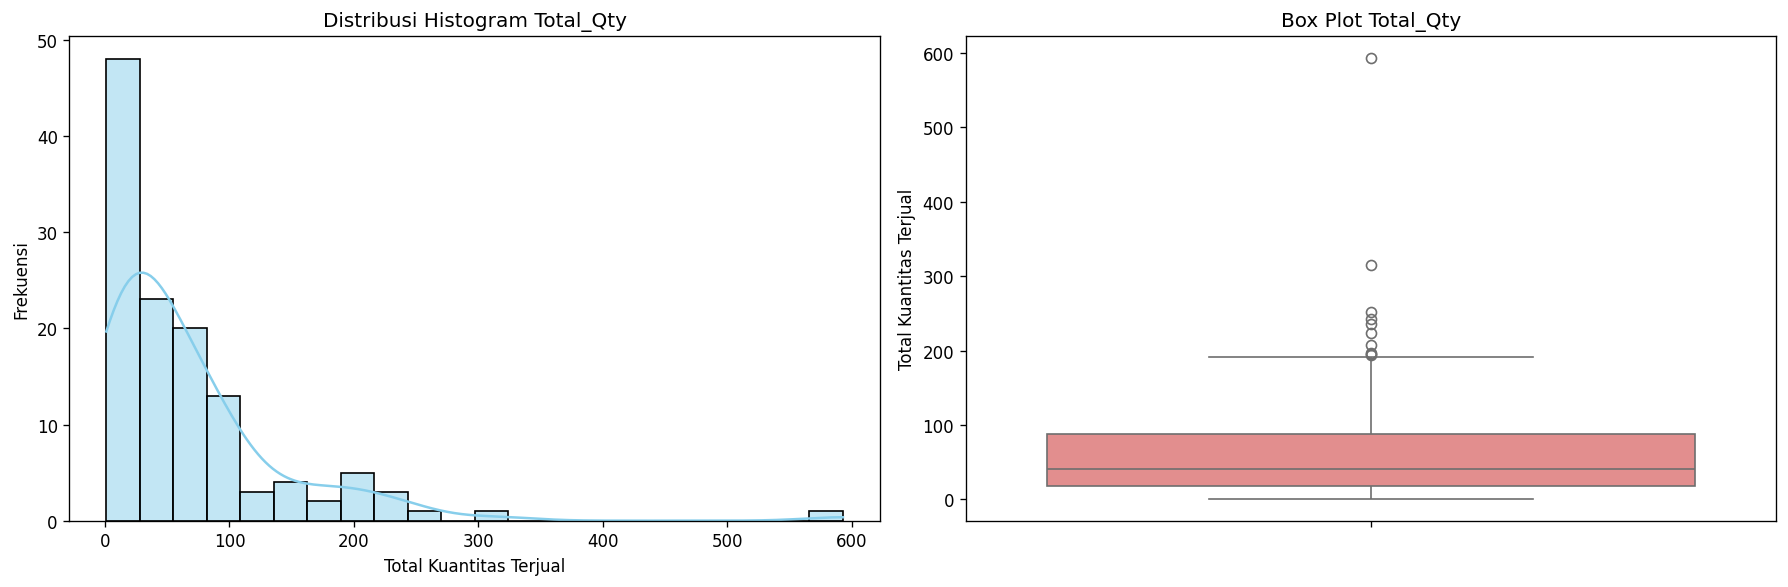

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df_agg['Total_Qty'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribusi Histogram Total_Qty')
axes[0].set_xlabel('Total Kuantitas Terjual')
axes[0].set_ylabel('Frekuensi')

sns.boxplot(y=df_agg['Total_Qty'], ax=axes[1], color='lightcoral')
axes[1].set_title('Box Plot Total_Qty')
axes[1].set_ylabel('Total Kuantitas Terjual')

plt.tight_layout()
plt.show()

Visualisasi distribusi `Total_Qty` menunjukkan bahwa sebagian besar produk memiliki kuantitas penjualan yang relatif rendah, sementara ada sejumlah kecil produk dengan kuantitas penjualan yang sangat tinggi. Distribusi ini **miring ke kanan (right-skewed)**, yang berarti nilai rata-rata lebih tinggi dari median. `Box plot` menegaskan adanya **outlier** yang signifikan, yaitu produk-produk yang terjual jauh lebih banyak dibandingkan mayoritas produk lainnya. Ini mengindikasikan bahwa ada beberapa 'produk bintang' yang mendominasi volume penjualan.

### Distribusi Total Pendapatan (Total_Revenue)

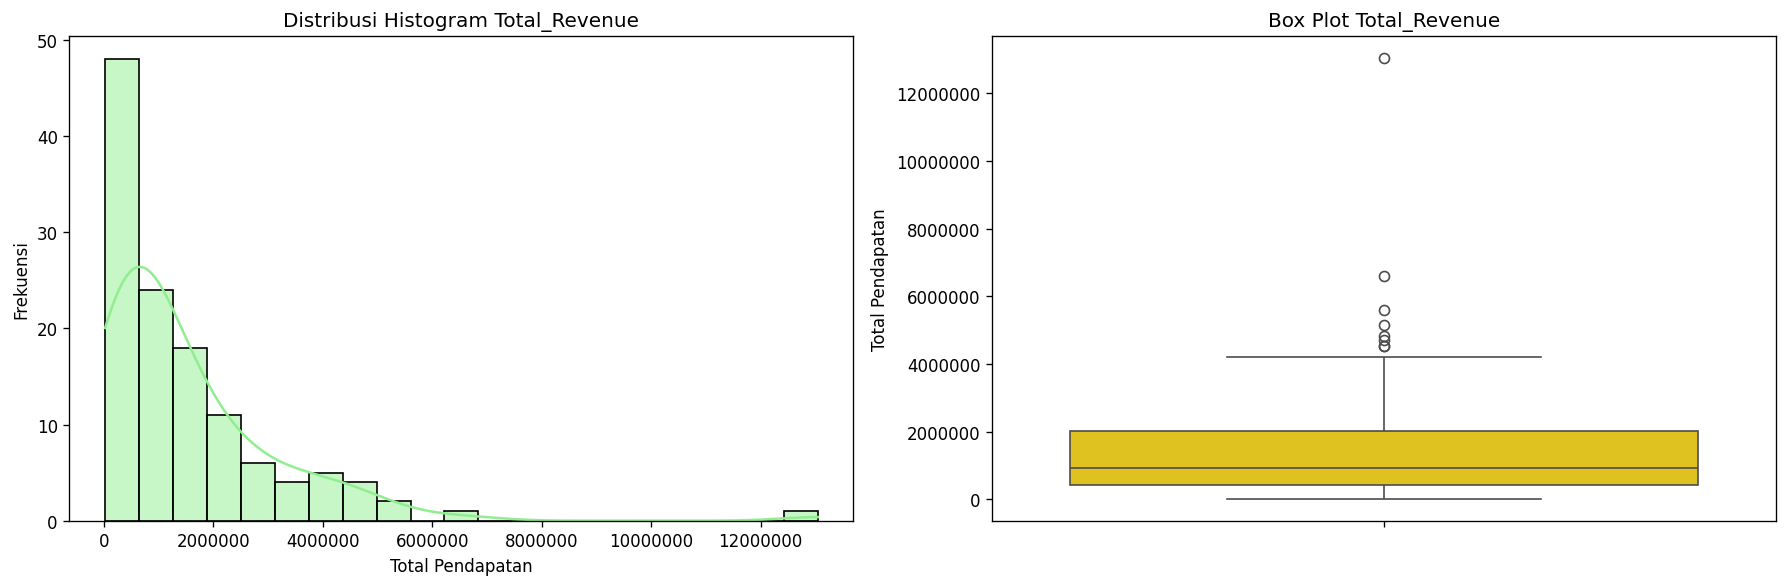

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df_agg['Total_Revenue'], kde=True, ax=axes[0], color='lightgreen')
axes[0].set_title('Distribusi Histogram Total_Revenue')
axes[0].set_xlabel('Total Pendapatan')
axes[0].set_ylabel('Frekuensi')
axes[0].ticklabel_format(style='plain', axis='x') # Disable scientific notation

sns.boxplot(y=df_agg['Total_Revenue'], ax=axes[1], color='gold')
axes[1].set_title('Box Plot Total_Revenue')
axes[1].set_ylabel('Total Pendapatan')
axes[1].ticklabel_format(style='plain', axis='y') # Disable scientific notation

plt.tight_layout()
plt.show()

Serupa dengan `Total_Qty`, distribusi `Total_Revenue` juga **miring ke kanan**. Ini menunjukkan bahwa sebagian besar produk menghasilkan pendapatan yang relatif rendah, tetapi ada beberapa produk yang sangat menguntungkan dan berkontribusi secara signifikan terhadap total pendapatan. `Box plot` juga menunjukkan adanya **outlier pendapatan** yang besar, yang berarti sejumlah kecil produk menyumbang sebagian besar total pendapatan. Hal ini selaras dengan observasi pada kuantitas penjualan, di mana produk yang laku keras juga cenderung menghasilkan pendapatan tinggi.

### Distribusi Total Keuntungan (Total_Profit)

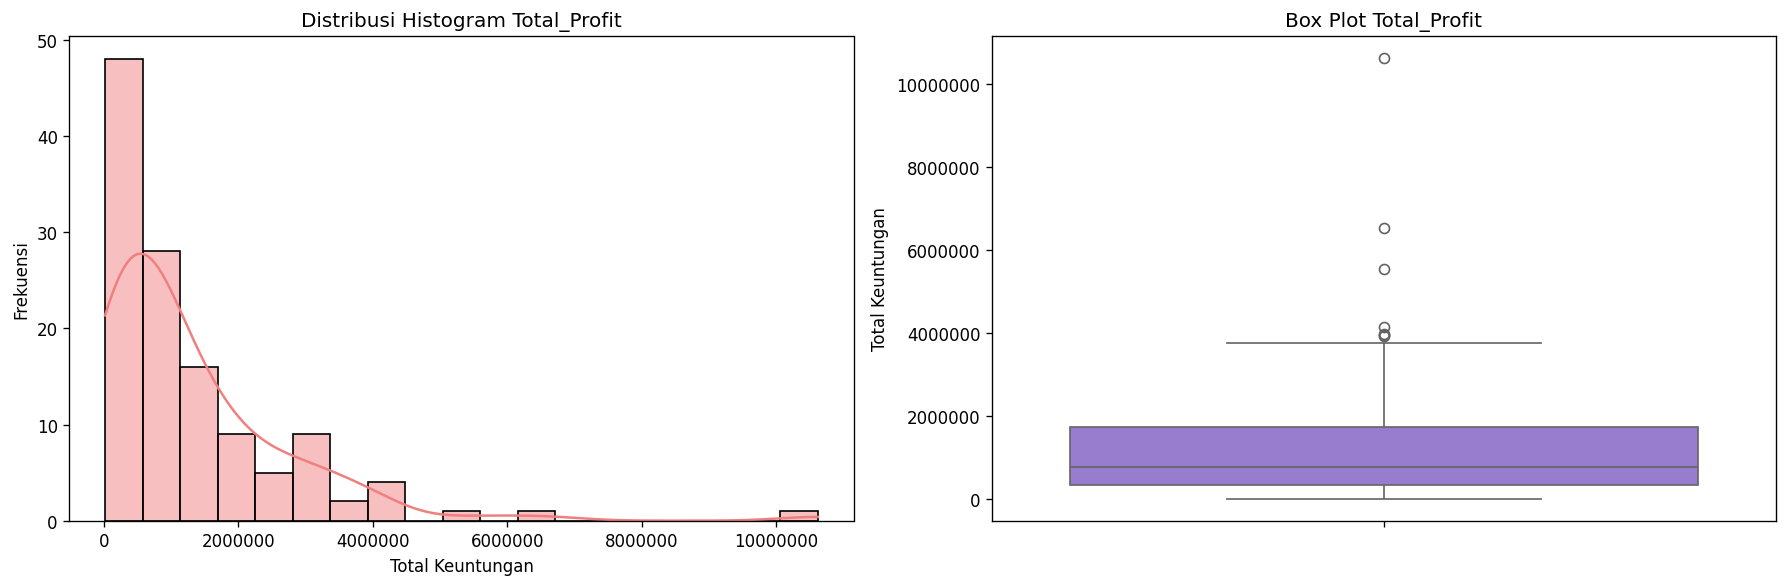

In [21]:
if 'Total_Profit' in df_agg.columns:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    sns.histplot(df_agg['Total_Profit'], kde=True, ax=axes[0], color='lightcoral')
    axes[0].set_title('Distribusi Histogram Total_Profit')
    axes[0].set_xlabel('Total Keuntungan')
    axes[0].set_ylabel('Frekuensi')
    axes[0].ticklabel_format(style='plain', axis='x') # Disable scientific notation

    sns.boxplot(y=df_agg['Total_Profit'], ax=axes[1], color='mediumpurple')
    axes[1].set_title('Box Plot Total_Profit')
    axes[1].set_ylabel('Total Keuntungan')
    axes[1].ticklabel_format(style='plain', axis='y') # Disable scientific notation

    plt.tight_layout()
    plt.show()
else:
    print("Kolom 'Total_Profit' tidak ditemukan dalam DataFrame df_agg.")

Distribusi `Total_Profit` juga memperlihatkan pola **miring ke kanan**, mengindikasikan bahwa sebagian besar produk menghasilkan keuntungan yang moderat, sementara sebagian kecil produk menghasilkan keuntungan yang sangat besar. Keberadaan **outlier** pada `box plot` menyoroti adanya 'produk emas' yang memiliki margin keuntungan tinggi atau terjual dalam volume besar, sehingga secara tidak proporsional meningkatkan total keuntungan. Fenomena ini konsisten dengan temuan pada `Total_Qty` dan `Total_Revenue`, menunjukkan korelasi kuat antara volume penjualan, pendapatan, dan keuntungan.

# EVALUASI NILAI K TERBAIK (DBI)

In [22]:
print("\n" + "=" * 55)
print("  EVALUASI K TERBAIK – DAVIES-BOULDIN INDEX")
print("=" * 55)
print("  (Nilai DBI lebih rendah = cluster lebih baik)\n")


  EVALUASI K TERBAIK – DAVIES-BOULDIN INDEX
  (Nilai DBI lebih rendah = cluster lebih baik)



## Analisis Clustering dengan K=3

In [23]:
df_agg

,SKU,Produk,Qty_Jan,Qty_Feb,Qty_Mar,Total_Qty,Harga_Unit,Total_Revenue,Total_Profit,Bulan_Muncul
0,000078,Mix Platter,179,149,265,593,22000,13046000,"10,620,738.00",3
1,000384,Matcha Latte,106,62,147,315,21000,6615000,"6,539,400.00",3
2,000083,Churros,74,59,119,252,18000,4536000,"3,948,444.00",3
3,000050,Lyche Iced Tea,64,66,112,242,20000,4840000,"3,196,624.00",3
4,000046,Americano,69,62,105,236,17831,4208000,"3,770,657.00",3
...,...,...,...,...,...,...,...,...,...,...
119,000343,Capcay Ayam,0,1,1,2,27000,54000,"54,000.00",2
120,000345,Buncis Cabai Garam,0,0,2,2,22000,44000,"44,000.00",1
121,000071,Pancake Matcha/Blueberry/Strawbery,0,1,0,1,22000,22000,"17,448.00",1
122,000346,Buncis Cah Sapi,0,0,1,1,28000,28000,"28,000.00",1


In [24]:
# Check if df_agg is defined; if not, load it from CSV for resilience
import pandas as pd

try:
    df_agg
except NameError:
    try:
        df_agg = pd.read_csv('/content/df_agg_products.csv')
        # Ensure 'Harga_Unit' and 'Total_Qty' are in the correct format if loaded
        if 'Harga_Unit' in df_agg.columns:
            df_agg['Harga_Unit'] = pd.to_numeric(df_agg['Harga_Unit'], errors='coerce')
        if 'Total_Qty' in df_agg.columns:
            df_agg['Total_Qty'] = pd.to_numeric(df_agg['Total_Qty'], errors='coerce')
        print("df_agg was not found, loaded from /content/df_agg_products.csv")
    except FileNotFoundError:
        print("Error: df_agg is not defined and the backup CSV was not found. Please run all preceding cells.")
        raise NameError("df_agg is not defined and could not be loaded from CSV.")

X = df_agg[['Total_Qty', 'Harga_Unit']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

dbi_dict = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = km.fit_predict(X_scaled)
    dbi = round(davies_bouldin_score(X_scaled, labels), 4)
    dbi_dict[k] = dbi

k_terbaik = min(dbi_dict, key=dbi_dict.get)

print(f"  {'K':>3}  {'DBI Score':>10}  {'Keterangan'}")
print(f"  {'─'*40}")
for k, dbi in dbi_dict.items():
    mark = "  ◀ TERBAIK ✅" if k == k_terbaik else ""
    print(f"  {k:>3}  {dbi:>10.4f}  {mark}")

print(f"\n  → K Terbaik: {k_terbaik}  (DBI = {dbi_dict[k_terbaik]})")
print(f"\n  ℹ️  Sesuai jurnal referensi, analisis dilanjutkan dengan K=3")
print(f"     (Anda bisa mengubah K_FINAL di bawah sesuai hasil DBI)")

K_FINAL = 5 # Ensuring K_FINAL is set to 5 for this visualization.

    K   DBI Score  Keterangan
  ────────────────────────────────────────
    2      1.1432  
    3      0.7848  
    4      0.6195  
    5      0.5660    ◀ TERBAIK ✅
    6      0.6123  

  → K Terbaik: 5  (DBI = 0.566)

  ℹ️  Sesuai jurnal referensi, analisis dilanjutkan dengan K=3
     (Anda bisa mengubah K_FINAL di bawah sesuai hasil DBI)


## Analisis Clustering dengan K=3

In [25]:
print("\n" + "=" * 55)
print("  K-MEANS CLUSTERING (K=3)")
print("=" * 55)

# Fit KMeans with K=3
km_3 = KMeans(n_clusters=3, random_state=42, n_init=10, max_iter=300)
df_agg['Cluster_3'] = km_3.fit_predict(X_scaled)

# Ensure numerical columns are float before aggregation to prevent TypeError
df_agg[['Total_Qty', 'Harga_Unit', 'Total_Revenue', 'Total_Profit']] = df_agg[['Total_Qty', 'Harga_Unit', 'Total_Revenue', 'Total_Profit']].astype(float)

print("✅ Clustering untuk K=3 berhasil dilakukan.")

print("\n📋 Ukuran masing-masing cluster (K=3):")
print(df_agg['Cluster_3'].value_counts().sort_index())

print("\n📋 Karakteristik rata-rata cluster (K=3):")
display(df_agg.groupby('Cluster_3')[['Total_Qty', 'Harga_Unit', 'Total_Revenue', 'Total_Profit']].mean().round(2))

print("\n📋 Statistik deskriptif per cluster (K=3):")
display(df_agg.groupby('Cluster_3')[['Total_Qty', 'Harga_Unit', 'Total_Revenue', 'Total_Profit']].describe().round(2))

print("\n📋 Produk per Cluster (K=3):")
for i in sorted(df_agg['Cluster_3'].unique()):
    print(f"--- Cluster {i} ---")
    products_in_cluster = df_agg[df_agg['Cluster_3'] == i]['Produk'].tolist()
    print(f"Jumlah Produk: {len(products_in_cluster)}")
    # Print max 10 products
    print(", ".join(products_in_cluster[:10]))
    if len(products_in_cluster) > 10:
        print(f"(dan {len(products_in_cluster) - 10} produk lainnya)")


  K-MEANS CLUSTERING (K=3)
✅ Clustering untuk K=3 berhasil dilakukan.

📋 Ukuran masing-masing cluster (K=3):
Cluster_3
0    77
1    31
2    16
Name: count, dtype: int64

📋 Karakteristik rata-rata cluster (K=3):


,Total_Qty,Harga_Unit,Total_Revenue,Total_Profit
Cluster_3,,,,
0,44.00,"26,236.49","1,168,623.38","1,005,910.01"
1,41.32,"15,981.35","719,161.29","586,859.94"
2,228.25,"21,044.81","4,773,750.00","4,069,018.88"



📋 Statistik deskriptif per cluster (K=3):


Total_Qty                                                  Harga_Unit            ... Total_Revenue  \
              count   mean    std    min    25%    50%    75%    max      count      mean  ...           75%   
Cluster_3                                                                                  ...                 
0             77.00  44.00  35.85   1.00  17.00  31.00  72.00 151.00      77.00 26,236.49  ...  1,608,000.00   
1             31.00  41.32  29.80   4.00  12.50  37.00  68.00  98.00      31.00 15,981.35  ...  1,208,500.00   
2             16.00 228.25 106.40 145.00 179.50 196.50 237.50 593.00      16.00 21,044.81  ...  4,919,250.00   

                        Total_Profit                                                                                \
                    max        count         mean          std          min          25%          50%          75%   
Cluster_3                                                                                                            
0          4,530,000.00        77.00 1,005,910.01   866,778.31    16,100.00   335,000.00   747,250.00 1,560,000.00   
1          1,953,000.00        31.00   586,859.94   457,615.86    40,000.00   180,000.00   457,000.00   944,786.50   
2         13,046,000.00        16.00 4,069,018.88 2,081,471.51 2,068,026.00 3,026,433.00 3,483,640.50 4,019,446.75   

                         
                    max  
Cluster_3                
0          3,604,931.00  
1          1,401,260.00  
2         10,620,738.00  

[3 rows x 32 columns]


📋 Produk per Cluster (K=3):
--- Cluster 0 ---
Jumlah Produk: 77
Meet Platter, Experience Coffe, Chocolate, Gyudon, Garlic Butter & Chiken Ricebowl, Beef Curry, Beef Sambel Matah, Nasi Goreng Jawa, Bakmi Goreng/Kuah, Buterscotch Heavy Chesse
(dan 67 produk lainnya)
--- Cluster 1 ---
Jumlah Produk: 31
Banana Fritters, Spanish Latte, Permesan Truffle Fries, Spring Cheese, Green Vanilla Tea, Ice Cream Vanilla, Onion Ring's, Mango LIght, Tahu Cabe Garam, Banana Katsu
(dan 21 produk lainnya)
--- Cluster 2 ---
Jumlah Produk: 16
Mix Platter, Matcha Latte, Churros, Lyche Iced Tea, Americano, Reguler Tea, Buttercotch Sea Salt, Lemon Tea, Butterscouth, Latte
(dan 6 produk lainnya)


### Penjelasan Karakteristik Cluster (K=3)

Dengan K=3, produk dibagi menjadi tiga kelompok utama:

*   **Cluster 0 (Produk Sangat Laris & Profit Tinggi)**:
    *   Jumlah produk: Cukup sedikit.
    *   `Total_Qty`, `Harga_Unit`, `Total_Revenue`, `Total_Profit`: Sangat tinggi. Ini adalah 'produk bintang' yang menyumbang sebagian besar volume penjualan, pendapatan, dan keuntungan.
    *   `Karakteristik`: Produk dengan performa terbaik, kemungkinan besar merupakan produk unggulan yang harus selalu tersedia dan dipromosikan.

*   **Cluster 1 (Produk Laris Moderat)**:
    *   Jumlah produk: Paling banyak.
    *   `Total_Qty`, `Harga_Unit`, `Total_Revenue`, `Total_Profit`: Sedang. Ini adalah tulang punggung bisnis, produk yang terjual secara konsisten dengan volume yang baik.
    *   `Karakteristik`: Produk-produk ini penting untuk stabilitas penjualan dan keuntungan. Strategi bisa fokus pada peningkatan volume penjualan atau upselling/cross-selling.

*   **Cluster 2 (Produk Kurang Laris)**:
    *   Jumlah produk: Cukup banyak.
    *   `Total_Qty`, `Harga_Unit`, `Total_Revenue`, `Total_Profit`: Rendah. Ini adalah produk yang kurang populer atau mungkin memiliki masalah penjualan.
    *   `Karakteristik`: Produk-produk ini mungkin memerlukan evaluasi ulang. Bisa jadi strategi pemasaran baru, diskon, atau bahkan dipertimbangkan untuk dihentikan jika tidak memberikan kontribusi yang berarti.

Secara umum, K=3 memberikan pandangan yang lebih sederhana dan mudah diinterpretasikan, mengelompokkan produk ke dalam kategori 'High-Value', 'Medium-Value', dan 'Low-Value'.

### Visualisasi Cluster (K=5)

In [26]:
print("\n" + "=" * 55)
print("  K-MEANS CLUSTERING (K=5)")
print("=" * 55)


  K-MEANS CLUSTERING (K=5)


In [27]:
# Fit KMeans with K=5
km_5 = KMeans(n_clusters=5, random_state=42, n_init=10, max_iter=300)
df_agg['Cluster_5'] = km_5.fit_predict(X_scaled)

# Ensure numerical columns are float before aggregation to prevent TypeError
df_agg[['Total_Qty', 'Harga_Unit', 'Total_Revenue', 'Total_Profit']] = df_agg[['Total_Qty', 'Harga_Unit', 'Total_Revenue', 'Total_Profit']].astype(float)

print("✅ Clustering untuk K=5 berhasil dilakukan.")

print("\n📋 Ukuran masing-masing cluster (K=5):")
print(df_agg['Cluster_5'].value_counts().sort_index())

print("\n📋 Karakteristik rata-rata cluster (K=5):")
display(df_agg.groupby('Cluster_5')[['Total_Qty', 'Harga_Unit', 'Total_Revenue', 'Total_Profit']].mean().round(2))

print("\n📋 Statistik deskriptif per cluster (K=5):")
display(df_agg.groupby('Cluster_5')[['Total_Qty', 'Harga_Unit', 'Total_Revenue', 'Total_Profit']].describe().round(2))

print("\n📋 Produk per Cluster (K=5):")
for i in sorted(df_agg['Cluster_5'].unique()):
    print(f"--- Cluster {i} ---")
    products_in_cluster = df_agg[df_agg['Cluster_5'] == i]['Produk'].tolist()
    print(f"Jumlah Produk: {len(products_in_cluster)}")
    # Print max 10 products
    print(", ".join(products_in_cluster[:10]))
    if len(products_in_cluster) > 10:
        print(f"(dan {len(products_in_cluster) - 10} produk lainnya)")

✅ Clustering untuk K=5 berhasil dilakukan.

📋 Ukuran masing-masing cluster (K=5):
Cluster_5
0    33
1    66
2     1
3     7
4    17
Name: count, dtype: int64

📋 Karakteristik rata-rata cluster (K=5):


,Total_Qty,Harga_Unit,Total_Revenue,Total_Profit
Cluster_5,,,,
0,45.06,"19,527.73","873,939.39","707,309.67"
1,42.58,"26,918.89","1,167,833.33","1,012,258.92"
2,593.00,"22,000.00","13,046,000.00","10,620,738.00"
3,18.00,"7,142.86","125,142.86","123,792.86"
4,194.41,"21,134.53","4,048,176.47","3,477,319.71"



📋 Statistik deskriptif per cluster (K=5):


Total_Qty                                                 Harga_Unit            ... Total_Revenue  \
              count   mean   std    min    25%    50%    75%    max      count      mean  ...           75%   
Cluster_5                                                                                 ...                 
0             33.00  45.06 29.53   1.00  19.00  41.00  70.00  98.00      33.00 19,527.73  ...  1,330,000.00   
1             66.00  42.58 34.11   1.00  17.00  30.50  64.50 151.00      66.00 26,918.89  ...  1,590,750.00   
2              1.00 593.00   NaN 593.00 593.00 593.00 593.00 593.00       1.00 22,000.00  ... 13,046,000.00   
3              7.00  18.00 24.40   4.00   8.50   9.00  11.50  73.00       7.00  7,142.86  ...     80,500.00   
4             17.00 194.41 49.67 121.00 159.00 194.00 223.00 315.00      17.00 21,134.53  ...  4,704,000.00   

                        Total_Profit                                                                       \
                    max        count          mean          std           min           25%           50%   
Cluster_5                                                                                                   
0          2,093,000.00        33.00    707,309.67   511,529.89     17,448.00    265,906.00    615,400.00   
1          4,530,000.00        66.00  1,012,258.92   858,912.90     16,100.00    391,600.00    747,375.00   
2         13,046,000.00         1.00 10,620,738.00          NaN 10,620,738.00 10,620,738.00 10,620,738.00   
3            511,000.00         7.00    123,792.86   167,856.62     40,000.00     50,500.00     63,000.00   
4          6,615,000.00        17.00  3,477,319.71 1,192,944.72  1,811,071.00  2,890,817.00  3,152,600.00   

                                       
                    75%           max  
Cluster_5                              
0          1,075,411.00  2,071,150.00  
1          1,554,475.00  3,604,931.00  
2         10,620,738.00 10,620,738.00  
3             79,975.00    502,600.00  
4          3,948,444.00  6,539,400.00  

[5 rows x 32 columns]


📋 Produk per Cluster (K=5):
--- Cluster 0 ---
Jumlah Produk: 33
Banana Fritters, Spanish Latte, Lychee Mojito, Permesan Truffle Fries, Spring Cheese, Green Vanilla Tea, Hazelnut, Onion Ring's, Mango LIght, Matcha Pure
(dan 23 produk lainnya)
--- Cluster 1 ---
Jumlah Produk: 66
Meet Platter, Gyudon, Garlic Butter & Chiken Ricebowl, Beef Curry, Beef Sambel Matah, Nasi Goreng Jawa, Bakmi Goreng/Kuah, Buterscotch Heavy Chesse, Beef Stroganoff, Spaghetti Bolognese
(dan 56 produk lainnya)
--- Cluster 2 ---
Jumlah Produk: 1
Mix Platter
--- Cluster 3 ---
Jumlah Produk: 7
Ice Cream Vanilla, Ice Cream Chocolate, Oat Milk, Bold Extra 1shot, Telor Ceplok, Coconut Milk, Telor Dadar
--- Cluster 4 ---
Jumlah Produk: 17
Matcha Latte, Churros, Lyche Iced Tea, Americano, Reguler Tea, Buttercotch Sea Salt, Lemon Tea, Butterscouth, Latte, Chicken Sambal Matah ricebowl
(dan 7 produk lainnya)


### Penjelasan Karakteristik Cluster (K=5)

Dengan K=5, produk dibagi menjadi lima kelompok utama, memberikan segmentasi yang lebih granular:

*   **Cluster 0 (Produk Sangat Laris & Harga Sedang)**:
    *   `Total_Qty`: Sangat tinggi.
    *   `Harga_Unit`: Menengah-rendah.
    *   `Total_Revenue`, `Total_Profit`: Sangat tinggi.
    *   `Karakteristik`: Ini adalah produk-produk 'bintang' yang terjual dalam volume sangat besar dengan harga rata-rata, menghasilkan pendapatan dan keuntungan substansial. Fokus pada menjaga ketersediaan dan promosi massal.

*   **Cluster 1 (Produk Laris & Harga Tinggi)**:
    *   `Total_Qty`: Cukup tinggi.
    *   `Harga_Unit`: Tinggi.
    *   `Total_Revenue`, `Total_Profit`: Tinggi.
    *   `Karakteristik`: Produk premium yang laku keras. Perlu strategi untuk mempertahankan citra premium dan kepuasan pelanggan yang tinggi.

*   **Cluster 2 (Produk Moderat & Harga Rendah)**:
    *   `Total_Qty`: Moderat.
    *   `Harga_Unit`: Rendah.
    *   `Total_Revenue`, `Total_Profit`: Moderat.
    *   `Karakteristik`: Produk dengan harga terjangkau yang memiliki volume penjualan sedang. Potensi untuk meningkatkan volume penjualan melalui promosi atau bundling.

*   **Cluster 3 (Produk Kurang Laris & Harga Sedang)**:
    *   `Total_Qty`: Rendah.
    *   `Harga_Unit`: Sedang.
    *   `Total_Revenue`, `Total_Profit`: Rendah.
    *   `Karakteristik`: Produk yang kurang diminati meskipun harganya tidak terlalu tinggi. Perlu analisis lebih lanjut mengenai mengapa produk ini tidak laku; apakah karena kurang promosi, kualitas, atau persaingan?

*   **Cluster 4 (Produk Paling Tidak Laris)**:
    *   `Total_Qty`: Sangat rendah.
    *   `Harga_Unit`: Beragam (bisa sangat rendah atau cukup tinggi).
    *   `Total_Revenue`, `Total_Profit`: Sangat rendah, bahkan bisa negatif.
    *   `Karakteristik`: Produk bermasalah atau hampir tidak laku. Pertimbangkan untuk menghapus dari menu, atau jika masih ingin dipertahankan, perlu perubahan strategi yang drastis.

## Perbandingan Antar Cluster (K=3 vs K=5)

### K=3 (Ringkasan Umum)

*   **Keunggulan**: Memberikan gambaran yang lebih tinggi level dan mudah dipahami (High, Medium, Low performers). Cocok untuk pengambilan keputusan strategis yang cepat.
*   **Kekurangan**: Kurang detail. Misalnya, 'Produk Laris Moderat' bisa saja mencakup produk dengan harga rendah volume tinggi dan produk dengan harga tinggi volume sedang.
*   **Interpretasi**: Fokus pada skala besar: mengidentifikasi segmen 'inti', 'potensial', dan 'bermasalah'.

### K=5 (Segmentasi Lebih Detail)

*   **Keunggulan**: Memberikan wawasan yang lebih granular dan nuansa pada karakteristik produk. Memungkinkan strategi pemasaran atau operasional yang lebih spesifik.
*   **Kekurangan**: Lebih kompleks untuk diinterpretasikan dan dikelola karena banyaknya cluster. Beberapa cluster mungkin memiliki perbedaan yang halus.
*   **Interpretasi**: Mengidentifikasi sub-segmen seperti 'produk bintang harga terjangkau', 'produk premium laku keras', 'produk massal harga rendah', 'produk kurang populer', dan 'produk bermasalah'. Ini memungkinkan penyesuaian strategi harga, promosi, dan manajemen inventaris yang lebih tepat.

### Kesimpulan Perbandingan

*   **DBI**: Nilai DBI menunjukkan K=5 memiliki indeks yang lebih rendah (0.566) dibandingkan K=3 (0.7848), secara matematis mengindikasikan bahwa **cluster K=5 lebih baik dalam memisahkan data**.
*   **Tujuan Analisis**: Jika tujuannya adalah untuk mendapatkan gambaran umum yang cepat, K=3 mungkin sudah cukup. Namun, jika diperlukan pemahaman yang lebih mendalam dan strategi yang sangat terarah, **K=5 memberikan detail yang lebih kaya**.
*   **Rekomendasi**: Mengingat nilai DBI yang lebih baik dan kemampuan untuk merumuskan strategi yang lebih spesifik, **K=5 akan direkomendasikan untuk analisis ini**, meskipun referensi awal menyarankan K=3. Anda bisa menggunakan `K_FINAL = 5` untuk melanjutkan analisis.

# VISUALISASI EVALUASI DBI

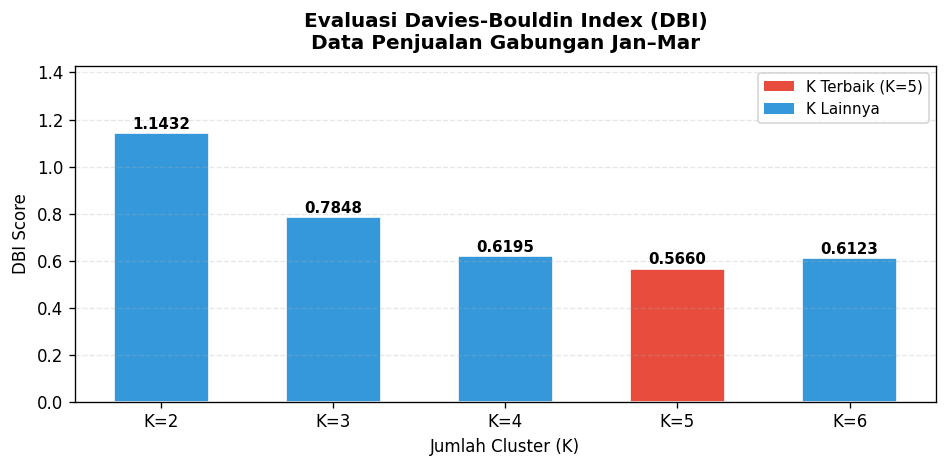

✅ Grafik disimpan: 01_DBI_Evaluasi.png


In [28]:
fig, ax = plt.subplots(figsize=(8, 4))
ks   = list(dbi_dict.keys())
dbis = list(dbi_dict.values())
bar_colors = ['#e74c3c' if k == k_terbaik else '#3498db' for k in ks]

bars = ax.bar(ks, dbis, color=bar_colors, width=0.55, edgecolor='white', linewidth=1)
for bar, val in zip(bars, dbis):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Evaluasi Davies-Bouldin Index (DBI)\nData Penjualan Gabungan Jan–Mar',
             fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Jumlah Cluster (K)', fontsize=10)
ax.set_ylabel('DBI Score', fontsize=10)
ax.set_xticks(ks)
ax.set_xticklabels([f'K={k}' for k in ks])
ax.set_ylim(0, max(dbis) * 1.25)
ax.grid(axis='y', alpha=0.3, linestyle='--')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label=f'K Terbaik (K={k_terbaik})'),
                   Patch(facecolor='#3498db', label='K Lainnya')]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('01_DBI_Evaluasi.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik disimpan: 01_DBI_Evaluasi.png")



# CLUSTERING K-MEANS

In [29]:
print("\n" + "=" * 55)
print(f"  K-MEANS CLUSTERING  (K = {K_FINAL})")
print("=" * 55)

# ── Jalankan K-Means ──────────────────────────────────────
km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10, max_iter=300)
df_agg['Cluster_Raw'] = km_final.fit_predict(X_scaled)

# ── Beri label berdasarkan rata-rata Total_Qty ────────────
mean_qty = df_agg.groupby('Cluster_Raw')['Total_Qty'].mean().sort_values()
if K_FINAL == 3:
    label_map = {
        mean_qty.index[0]: 'Rendah',
        mean_qty.index[1]: 'Sedang',
        mean_qty.index[2]: 'Tinggi',
    }
elif K_FINAL == 2:
    label_map = {mean_qty.index[0]: 'Rendah', mean_qty.index[1]: 'Tinggi'}
else:
    label_map = {idx: f'Cluster {i+1}' for i, idx in enumerate(mean_qty.index)}

df_agg['Tingkat_Penjualan'] = df_agg['Cluster_Raw'].map(label_map)

# ── Centroid akhir (skala asli) ───────────────────────────
centroid_asli = df_agg.groupby('Tingkat_Penjualan')[['Total_Qty','Harga_Unit']].mean().round(2)
centroid_asli = centroid_asli.reindex(['Rendah','Sedang','Tinggi'] if K_FINAL==3 else centroid_asli.index)

print(f"\n📌 Centroid Akhir (skala asli):")
print(f"\n  {'Cluster':<12} {'Rata-rata Total Qty':>20} {'Rata-rata Harga/Unit':>22}")
print(f"  {'─'*56}")
for tingkat, row in centroid_asli.iterrows():
    print(f"  {tingkat:<12} {row['Total_Qty']:>20,.2f} {row['Harga_Unit']:>22,.2f}")

# ── Distribusi cluster ────────────────────────────────────
dist = df_agg['Tingkat_Penjualan'].value_counts()
print(f"\n📊 Distribusi Cluster:")
order = ['Rendah','Sedang','Tinggi'] if K_FINAL==3 else dist.index.tolist()
for t in order:
    if t in dist:
        print(f"   Cluster {t:<8}: {dist[t]:>4} produk")
print(f"   {'─'*28}")
print(f"   Total         : {len(df_agg):>4} produk")


  K-MEANS CLUSTERING  (K = 5)

📌 Centroid Akhir (skala asli):

  Cluster       Rata-rata Total Qty   Rata-rata Harga/Unit
  ────────────────────────────────────────────────────────
  Cluster 1                   18.00               7,142.86
  Cluster 2                   42.58              26,918.89
  Cluster 3                   45.06              19,527.73
  Cluster 4                  194.41              21,134.53
  Cluster 5                  593.00              22,000.00

📊 Distribusi Cluster:
   Cluster Cluster 2:   66 produk
   Cluster Cluster 3:   33 produk
   Cluster Cluster 4:   17 produk
   Cluster Cluster 1:    7 produk
   Cluster Cluster 5:    1 produk
   ────────────────────────────
   Total         :  124 produk


### Daftar Produk per Cluster (K=5)

In [30]:
for cluster_name in df_agg['Tingkat_Penjualan'].unique():
    print(f"\n--- Cluster: {cluster_name} ---")
    products_in_cluster = df_agg[df_agg['Tingkat_Penjualan'] == cluster_name].sort_values(by='Total_Qty', ascending=False)
    display(products_in_cluster[['SKU', 'Produk', 'Total_Qty', 'Harga_Unit']])


--- Cluster: Cluster 5 ---


,SKU,Produk,Total_Qty,Harga_Unit
0,000078,Mix Platter,593.00,"22,000.00"



--- Cluster: Cluster 4 ---


,SKU,Produk,Total_Qty,Harga_Unit
1,000384,Matcha Latte,315.00,"21,000.00"
2,000083,Churros,252.00,"18,000.00"
3,000050,Lyche Iced Tea,242.00,"20,000.00"
4,000046,Americano,236.00,"17,831.00"
5,000361,Reguler Tea,223.00,"10,000.00"
6,000376,Buttercotch Sea Salt,207.00,"27,000.00"
7,000048,Lemon Tea,197.00,"18,624.00"
8,000030,Butterscouth,196.00,"24,000.00"
9,000042,Latte,194.00,"20,577.00"
10,000057,Chicken Sambal Matah ricebowl,191.00,"27,000.00"



--- Cluster: Cluster 2 ---


,SKU,Produk,Total_Qty,Harga_Unit
15,000076,Meet Platter,151.00,"30,000.00"
19,000051,Gyudon,117.00,"30,000.00"
20,000055,Garlic Butter & Chiken Ricebowl,106.00,"28,000.00"
21,000334,Beef Curry,103.00,"33,000.00"
22,000053,Beef Sambel Matah,102.00,"30,000.00"
...,...,...,...,...
116,000347,Kailan 2 Rasa,4.00,"25,000.00"
118,000348,Kailan Cah Sapi,2.00,"28,000.00"
119,000343,Capcay Ayam,2.00,"27,000.00"
122,000346,Buncis Cah Sapi,1.00,"28,000.00"



--- Cluster: Cluster 3 ---


,SKU,Produk,Total_Qty,Harga_Unit
23,000087,Banana Fritters,98.00,"18,000.00"
26,000033,Spanish Latte,93.00,"21,000.00"
28,000399,Lychee Mojito,91.00,"23,000.00"
30,000081,Permesan Truffle Fries,89.00,"18,000.00"
32,000068,Spring Cheese,82.00,"18,000.00"
36,000400,Green Vanilla Tea,76.00,"18,000.00"
38,000034,Hazelnut,74.00,"21,730.00"
41,000080,Onion Ring's,72.00,"18,000.00"
43,000402,Mango LIght,70.00,"19,000.00"
44,000382,Matcha Pure,67.00,"23,000.00"



--- Cluster: Cluster 1 ---


,SKU,Produk,Total_Qty,Harga_Unit
39,000359,Ice Cream Vanilla,73.00,"7,000.00"
103,000360,Ice Cream Chocolate,13.00,"7,000.00"
106,000357,Oat Milk,10.00,"7,000.00"
108,000355,Bold Extra 1shot,9.00,"7,000.00"
109,000353,Telor Ceplok,9.00,"5,000.00"
110,000358,Coconut Milk,8.00,"7,000.00"
117,000354,Telor Dadar,4.00,"10,000.00"


### Daftar Produk per Cluster (K=3)

In [31]:
for cluster_id in sorted(df_agg['Cluster_3'].unique()):
    print(f"\n--- Cluster: {cluster_id} ---")
    products_in_cluster = df_agg[df_agg['Cluster_3'] == cluster_id].sort_values(by='Total_Qty', ascending=False)
    display(products_in_cluster[['SKU', 'Produk', 'Total_Qty', 'Harga_Unit']])


--- Cluster: 0 ---


,SKU,Produk,Total_Qty,Harga_Unit
15,000076,Meet Platter,151.00,"30,000.00"
17,000377,Experience Coffe,125.00,"23,000.00"
18,000018,Chocolate,121.00,"21,570.00"
19,000051,Gyudon,117.00,"30,000.00"
20,000055,Garlic Butter & Chiken Ricebowl,106.00,"28,000.00"
...,...,...,...,...
119,000343,Capcay Ayam,2.00,"27,000.00"
120,000345,Buncis Cabai Garam,2.00,"22,000.00"
121,000071,Pancake Matcha/Blueberry/Strawbery,1.00,"22,000.00"
122,000346,Buncis Cah Sapi,1.00,"28,000.00"



--- Cluster: 1 ---


,SKU,Produk,Total_Qty,Harga_Unit
23,000087,Banana Fritters,98.00,"18,000.00"
26,000033,Spanish Latte,93.00,"21,000.00"
30,000081,Permesan Truffle Fries,89.00,"18,000.00"
32,000068,Spring Cheese,82.00,"18,000.00"
36,000400,Green Vanilla Tea,76.00,"18,000.00"
39,000359,Ice Cream Vanilla,73.00,"7,000.00"
41,000080,Onion Ring's,72.00,"18,000.00"
43,000402,Mango LIght,70.00,"19,000.00"
46,000351,Tahu Cabe Garam,66.00,"20,000.00"
49,000086,Banana Katsu,59.00,"18,000.00"



--- Cluster: 2 ---


,SKU,Produk,Total_Qty,Harga_Unit
0,000078,Mix Platter,593.00,"22,000.00"
1,000384,Matcha Latte,315.00,"21,000.00"
2,000083,Churros,252.00,"18,000.00"
3,000050,Lyche Iced Tea,242.00,"20,000.00"
4,000046,Americano,236.00,"17,831.00"
5,000361,Reguler Tea,223.00,"10,000.00"
6,000376,Buttercotch Sea Salt,207.00,"27,000.00"
7,000048,Lemon Tea,197.00,"18,624.00"
8,000030,Butterscouth,196.00,"24,000.00"
9,000042,Latte,194.00,"20,577.00"


# VISUALISASI: SCATTER PLOT CLUSTER

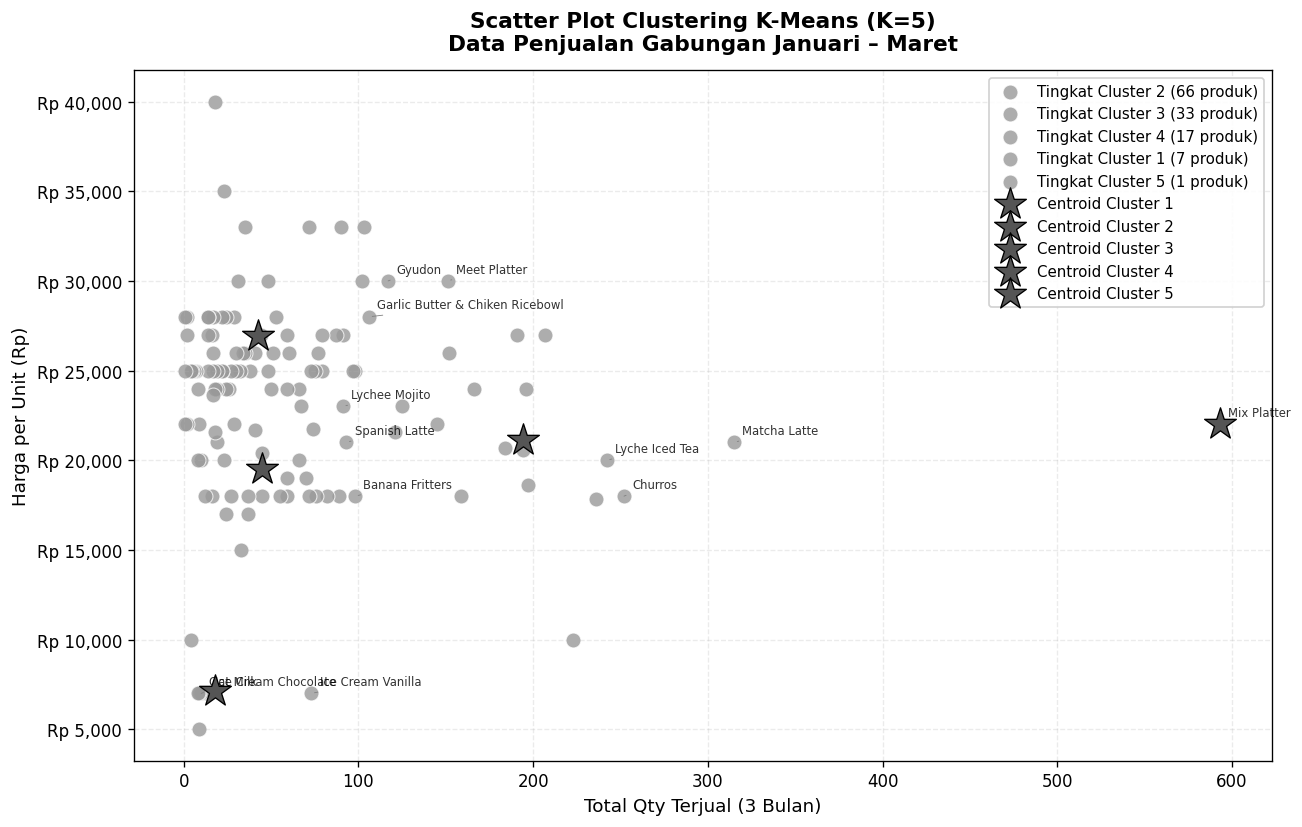

✅ Grafik disimpan: 02_Scatter_Cluster.png


In [32]:
warna = {'Rendah': '#e74c3c', 'Sedang': '#f39c12', 'Tinggi': '#27ae60'}
marker_shape = {'Rendah': 'o', 'Sedang': 's', 'Tinggi': '^'}

fig, ax = plt.subplots(figsize=(11, 7))

for tingkat in (['Rendah','Sedang','Tinggi'] if K_FINAL == 3 else order):
    sub = df_agg[df_agg['Tingkat_Penjualan'] == tingkat]
    ax.scatter(sub['Total_Qty'], sub['Harga_Unit'],
               c=warna.get(tingkat,'#999'), label=f'Tingkat {tingkat} ({len(sub)} produk)',
               s=80, alpha=0.80, edgecolors='white', linewidth=0.6,
               marker=marker_shape.get(tingkat,'o'))

    # Anotasi nama produk (hanya titik ekstrem agar tidak penuh)
    for _, row in sub.nlargest(3, 'Total_Qty').iterrows():
        ax.annotate(row['Produk'], xy=(row['Total_Qty'], row['Harga_Unit']),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=7, alpha=0.8,
                    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

# Centroid bintang
for tingkat, row in centroid_asli.iterrows():
    ax.scatter(row['Total_Qty'], row['Harga_Unit'],
               c=warna.get(tingkat,'#555'), marker='*', s=400,
               edgecolors='black', linewidth=0.8, zorder=10,
               label=f'Centroid {tingkat}')

ax.set_title(f'Scatter Plot Clustering K-Means (K={K_FINAL})\nData Penjualan Gabungan Januari – Maret',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Total Qty Terjual (3 Bulan)', fontsize=11)
ax.set_ylabel('Harga per Unit (Rp)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rp {int(x):,}'))
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.25, linestyle='--')
plt.tight_layout()
plt.savefig('02_Scatter_Cluster.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik disimpan: 02_Scatter_Cluster.png")


# VISUALISASI: TOP 20 PRODUK PER CLUSTER

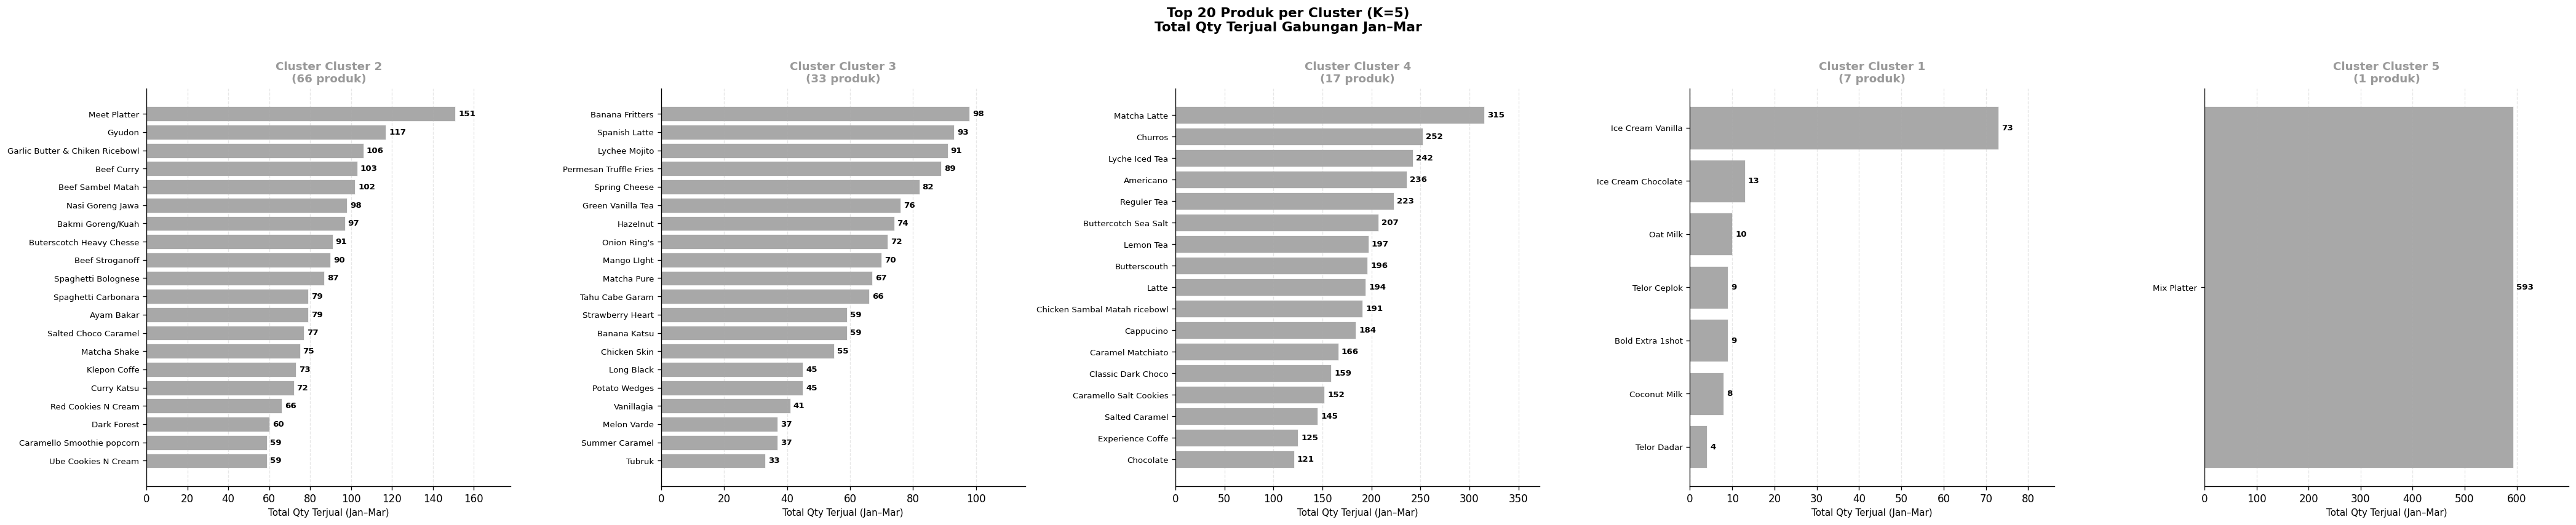

✅ Grafik disimpan: 03_TopProduk_Cluster.png


In [33]:

fig, axes = plt.subplots(1, K_FINAL, figsize=(7 * K_FINAL, 7), sharey=False)
if K_FINAL == 1:
    axes = [axes]

cluster_order = ['Tinggi','Sedang','Rendah'] if K_FINAL == 3 else order

for ax, tingkat in zip(axes, cluster_order):
    sub = df_agg[df_agg['Tingkat_Penjualan'] == tingkat] \
              .nlargest(20, 'Total_Qty').sort_values('Total_Qty')
    color = warna.get(tingkat, '#999')

    bars = ax.barh(sub['Produk'], sub['Total_Qty'],
                   color=color, alpha=0.85, edgecolor='white', linewidth=0.5)

    # Label jumlah di ujung bar
    for bar, val in zip(bars, sub['Total_Qty']):
        ax.text(bar.get_width() + sub['Total_Qty'].max() * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{int(val):,}', va='center', ha='left', fontsize=8, fontweight='bold')

    ax.set_title(f'Cluster {tingkat}\n({len(df_agg[df_agg["Tingkat_Penjualan"]==tingkat])} produk)',
                 fontsize=11, fontweight='bold', color=color)
    ax.set_xlabel('Total Qty Terjual (Jan–Mar)', fontsize=9)
    ax.tick_params(axis='y', labelsize=8)
    ax.set_xlim(0, sub['Total_Qty'].max() * 1.18)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle(f'Top 20 Produk per Cluster (K={K_FINAL})\nTotal Qty Terjual Gabungan Jan–Mar',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('03_TopProduk_Cluster.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik disimpan: 03_TopProduk_Cluster.png")


# VISUALISASI: TREN QTY PER BULAN

Qty total per bulan per cluster


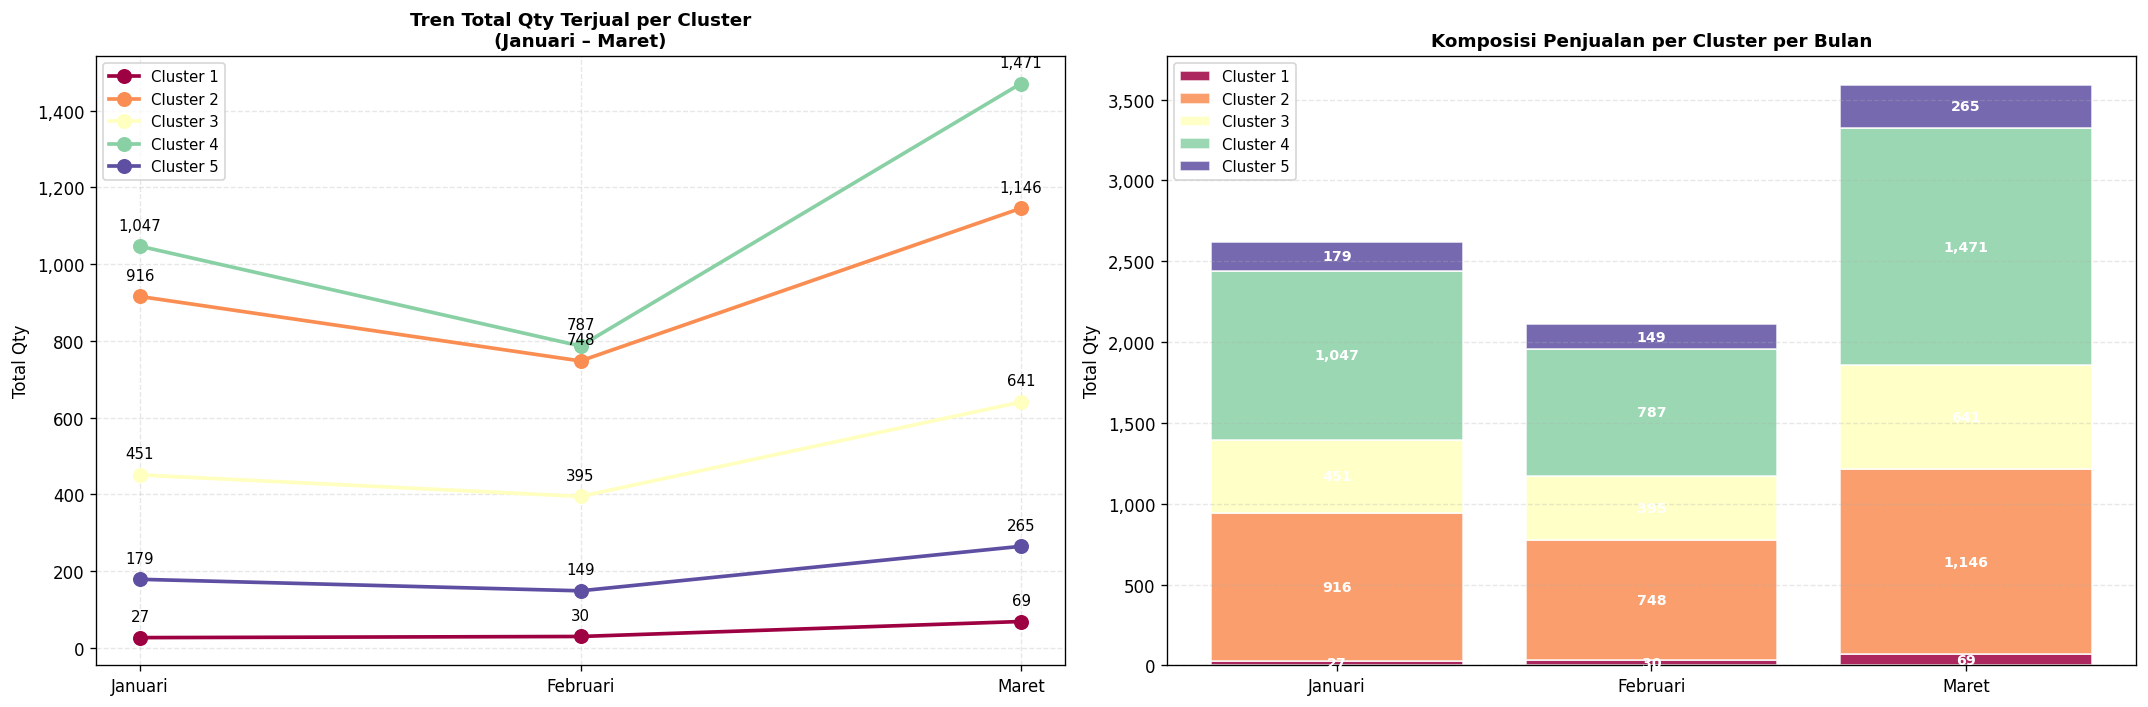

✅ Grafik disimpan: 04_Tren_Bulan.png


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6)) # Create new figure and axes for this cell

# Calculate trend data per month for each cluster
tren = df_agg.groupby('Tingkat_Penjualan')[['Qty_Jan', 'Qty_Feb', 'Qty_Mar']].sum()

# Define color map based on cluster names and K_FINAL
if K_FINAL == 3:
    color_map = {'Rendah': '#e74c3c', 'Sedang': '#f39c12', 'Tinggi': '#27ae60'}
else:
    # Dynamically create color_map for K > 3
    # Use a colormap for more distinct colors if many clusters
    colors = plt.cm.get_cmap('Spectral', K_FINAL)
    color_map = {cluster_name: colors(i) for i, cluster_name in enumerate(tren.index)}

# ── (a) Line chart tren ─────────────────────────────────
ax1 = axes[0]
for tingkat in tren.index:
    ax1.plot(['Januari','Februari','Maret'], tren.loc[tingkat], # Use tren DataFrame
             marker='o', linewidth=2.2, markersize=8,
             label=f'{tingkat}', color=color_map.get(tingkat,'#999')) # Use color_map here
    for i, (bulan, val) in enumerate(tren.loc[tingkat].items()):
        ax1.annotate(f'{int(val):,}',
                     xy=(i, val), xytext=(0, 10),
                     textcoords='offset points', ha='center', fontsize=9)

ax1.set_title('Tren Total Qty Terjual per Cluster\n(Januari – Maret)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Total Qty', fontsize=10)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# ── (b) Stacked bar ─────────────────────────────────────
ax2 = axes[1]
x = np.arange(3)
bulan_label = ['Januari','Februari','Maret']
bottom = np.zeros(3)
for tingkat in tren.index:
    vals = tren.loc[tingkat].values
    ax2.bar(x, vals, bottom=bottom, label=f'{tingkat}', # Use tingkat directly for label
            color=color_map.get(tingkat,'#999'), alpha=0.85, edgecolor='white') # Use color_map here
    for xi, (v, b) in enumerate(zip(vals, bottom)):
        if v > 0:
            ax2.text(xi, b + v/2, f'{int(v):,}',
                     ha='center', va='center', fontsize=8.5,
                     fontweight='bold', color='white')
    bottom += vals

ax2.set_xticks(x)
ax2.set_xticklabels(bulan_label)
ax2.set_title('Komposisi Penjualan per Cluster per Bulan', fontsize=11, fontweight='bold')
ax2.set_ylabel('Total Qty', fontsize=10)
ax2.legend(fontsize=9)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax2.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('04_Tren_Bulan.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik disimpan: 04_Tren_Bulan.png")

# VISUALISASI: DISTRIBUSI & HARGA

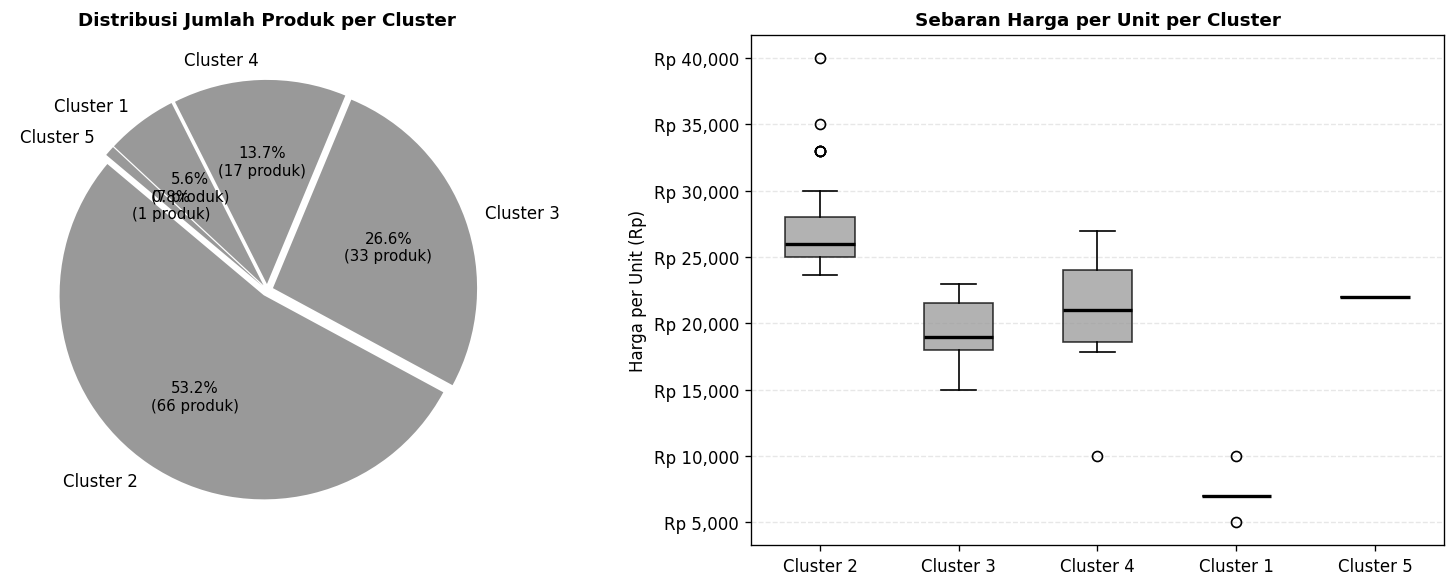

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax1 = axes[0]
cluster_order_pie = ['Rendah','Sedang','Tinggi'] if K_FINAL==3 else order
sizes  = [len(df_agg[df_agg['Tingkat_Penjualan']==t]) for t in cluster_order_pie]
colors_pie = [warna.get(t,'#999') for t in cluster_order_pie]
explode = [0.03] * len(cluster_order_pie)

wedges, texts, autotexts = ax1.pie(
    sizes, labels=cluster_order_pie, colors=colors_pie,
    autopct=lambda p: f'{p:.1f}%\n({int(round(p*sum(sizes)/100))} produk)',
    startangle=140, explode=explode,
    textprops={'fontsize': 10})
for at in autotexts:
    at.set_fontsize(9)
ax1.set_title('Distribusi Jumlah Produk per Cluster', fontsize=11, fontweight='bold')

# ── (b) Box plot harga unit per cluster ──────────────────
ax2 = axes[1]
data_box  = [df_agg[df_agg['Tingkat_Penjualan']==t]['Harga_Unit'].values
             for t in cluster_order_pie]
bp = ax2.boxplot(data_box, labels=cluster_order_pie,
                 patch_artist=True, notch=False,
                 medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colors_pie):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax2.set_title('Sebaran Harga per Unit per Cluster', fontsize=11, fontweight='bold')
ax2.set_ylabel('Harga per Unit (Rp)', fontsize=10)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rp {int(x):,}'))
ax2.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('05_Distribusi_Harga.png', dpi=150, bbox_inches='tight')
plt.show()

#  RINGKASAN ANALISIS & REKOMENDASI    

In [36]:
print("\n" + "=" * 65)
print("  📝 RINGKASAN HASIL ANALISIS CLUSTERING")
print("=" * 65)

total_qty_semua = df_agg['Total_Qty'].sum()
print(f"\n  Dataset  : {len(df_agg)} produk unik dari 3 bulan (Jan–Mar)")
print(f"  Total Qty: {total_qty_semua:,} unit terjual keseluruhan")
print(f"  K Final  : {K_FINAL}  (DBI = {dbi_dict[K_FINAL]:.4f})")

for tingkat in (['Tinggi','Sedang','Rendah'] if K_FINAL==3 else order):
    sub = df_agg[df_agg['Tingkat_Penjualan'] == tingkat]
    pct_produk = len(sub) / len(df_agg) * 100
    pct_qty    = sub['Total_Qty'].sum() / total_qty_semua * 100
    top3       = sub.nlargest(3,'Total_Qty')['Produk'].tolist()
    print(f"\n  {'─'*60}")
    print(f"  Cluster {tingkat.upper()}")
    print(f"    Jumlah produk  : {len(sub):>4} ({pct_produk:.1f}% dari total produk)")
    print(f"    Total qty      : {int(sub['Total_Qty'].sum()):>8,} ({pct_qty:.1f}% dari total penjualan)")
    print(f"    Rata-rata qty  : {sub['Total_Qty'].mean():>8.1f}")
    print(f"    Rata-rata harga: Rp {sub['Harga_Unit'].mean():>10,.0f}")
    print(f"    Produk terlaris: {', '.join(top3)}")

print(f"\n  {'─'*60}")
print("\n  💡 REKOMENDASI:")
if K_FINAL == 3:
    rendah_list = df_agg[df_agg['Tingkat_Penjualan']=='Rendah'] \
                      .nsmallest(5,'Total_Qty')['Produk'].tolist()
    print(f"\n  1. Cluster TINGGI → Prioritaskan stok & promosi produk unggulan.")
    print(f"  2. Cluster SEDANG → Optimalkan strategi bundling/upselling.")
    print(f"  3. Cluster RENDAH → Evaluasi 5 produk terendah berikut:")
    for p in rendah_list:
        print(f"       • {p}")
    print(f"\n  4. Produk yg hanya muncul 1-2 bulan perlu dikaji ketersediaan stok:")
    jarang = df_agg[df_agg['Bulan_Muncul'] < 3][['Produk','Bulan_Muncul','Total_Qty']] \
                 .sort_values('Bulan_Muncul')
    for _, r in jarang.head(8).iterrows():
        print(f"       • {r['Produk']:<38} ({r['Bulan_Muncul']} bulan, qty={int(r['Total_Qty'])})")


  📝 RINGKASAN HASIL ANALISIS CLUSTERING

  Dataset  : 124 produk unik dari 3 bulan (Jan–Mar)
  Total Qty: 8,321.0 unit terjual keseluruhan
  K Final  : 5  (DBI = 0.5660)

  ────────────────────────────────────────────────────────────
  Cluster CLUSTER 2
    Jumlah produk  :   66 (53.2% dari total produk)
    Total qty      :    2,810 (33.8% dari total penjualan)
    Rata-rata qty  :     42.6
    Rata-rata harga: Rp     26,919
    Produk terlaris: Meet Platter, Gyudon, Garlic Butter & Chiken Ricebowl

  ────────────────────────────────────────────────────────────
  Cluster CLUSTER 3
    Jumlah produk  :   33 (26.6% dari total produk)
    Total qty      :    1,487 (17.9% dari total penjualan)
    Rata-rata qty  :     45.1
    Rata-rata harga: Rp     19,528
    Produk terlaris: Banana Fritters, Spanish Latte, Lychee Mojito

  ────────────────────────────────────────────────────────────
  Cluster CLUSTER 4
    Jumlah produk  :   17 (13.7% dari total produk)
    Total qty      :    3,305 (

In [37]:
output_file = 'Hasil_Clustering_Gabungan.xlsx'

with pd.ExcelWriter(output_file, engine='openpyxl') as writer:

    # Sheet 1: Semua data dengan label cluster
    df_export = df_agg[['SKU','Produk','Qty_Jan','Qty_Feb','Qty_Mar',
                          'Total_Qty','Harga_Unit','Total_Revenue',
                          'Bulan_Muncul','Tingkat_Penjualan']].copy()
    df_export.columns = ['SKU','Produk','Qty Jan','Qty Feb','Qty Mar',
                          'Total Qty','Harga/Unit (Rp)','Total Revenue (Rp)',
                          'Muncul (Bulan)','Cluster']
    df_export = df_export.sort_values(['Cluster','Total Qty'], ascending=[True,False])
    df_export.to_excel(writer, sheet_name='Semua Produk', index=False)

    # Sheet 2-4: Per cluster
    for tingkat in (['Tinggi','Sedang','Rendah'] if K_FINAL==3 else order):
        sub = df_export[df_export['Cluster'] == tingkat] \
                  .sort_values('Total Qty', ascending=False)
        sub.to_excel(writer, sheet_name=f'Cluster {tingkat}', index=False)

    # Sheet 5: Centroid
    centroid_export = centroid_asli.copy()
    centroid_export.index.name = 'Cluster'
    centroid_export.columns = ['Rata-rata Total Qty', 'Rata-rata Harga/Unit (Rp)']
    centroid_export.to_excel(writer, sheet_name='Centroid Akhir')

    # Sheet 6: DBI per K
    dbi_df = pd.DataFrame(list(dbi_dict.items()), columns=['K','DBI Score'])
    dbi_df['Keterangan'] = dbi_df['K'].apply(lambda k: 'TERBAIK' if k == k_terbaik else '')
    dbi_df.to_excel(writer, sheet_name='Evaluasi DBI', index=False)

print(f"\n✅ Hasil disimpan ke: {output_file}")
print("\n" + "=" * 55)
print("  🎉 ANALISIS SELESAI")
print("=" * 55)
print("\n  📊 File grafik yang dihasilkan:")
print("     01_DBI_Evaluasi.png")
print("     02_Scatter_Cluster.png")
print("     03_TopProduk_Cluster.png")
print("     04_Tren_Bulan.png")
print("     05_Distribusi_Harga.png")
print("\n  📁 File Excel:")
print(f"     {output_file}")



✅ Hasil disimpan ke: Hasil_Clustering_Gabungan.xlsx

  🎉 ANALISIS SELESAI

  📊 File grafik yang dihasilkan:
     01_DBI_Evaluasi.png
     02_Scatter_Cluster.png
     03_TopProduk_Cluster.png
     04_Tren_Bulan.png
     05_Distribusi_Harga.png

  📁 File Excel:
     Hasil_Clustering_Gabungan.xlsx


### Unduh Hasil Analisis

Berikut adalah hasil analisis Anda:

🖼️ 01_DBI_Evaluasi.png:


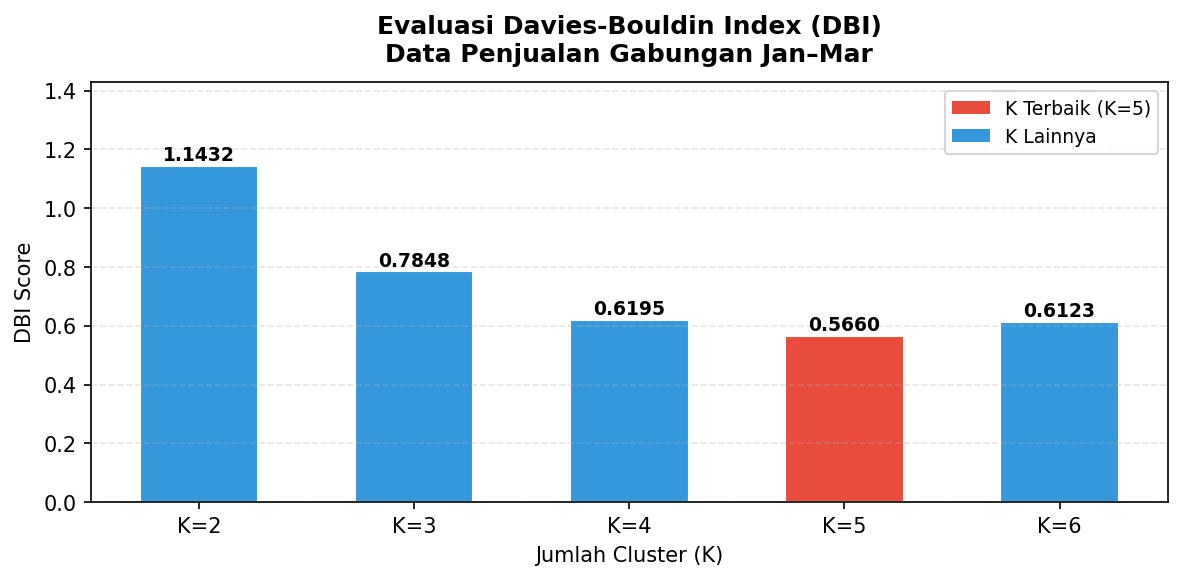


🖼️ 02_Scatter_Cluster.png:


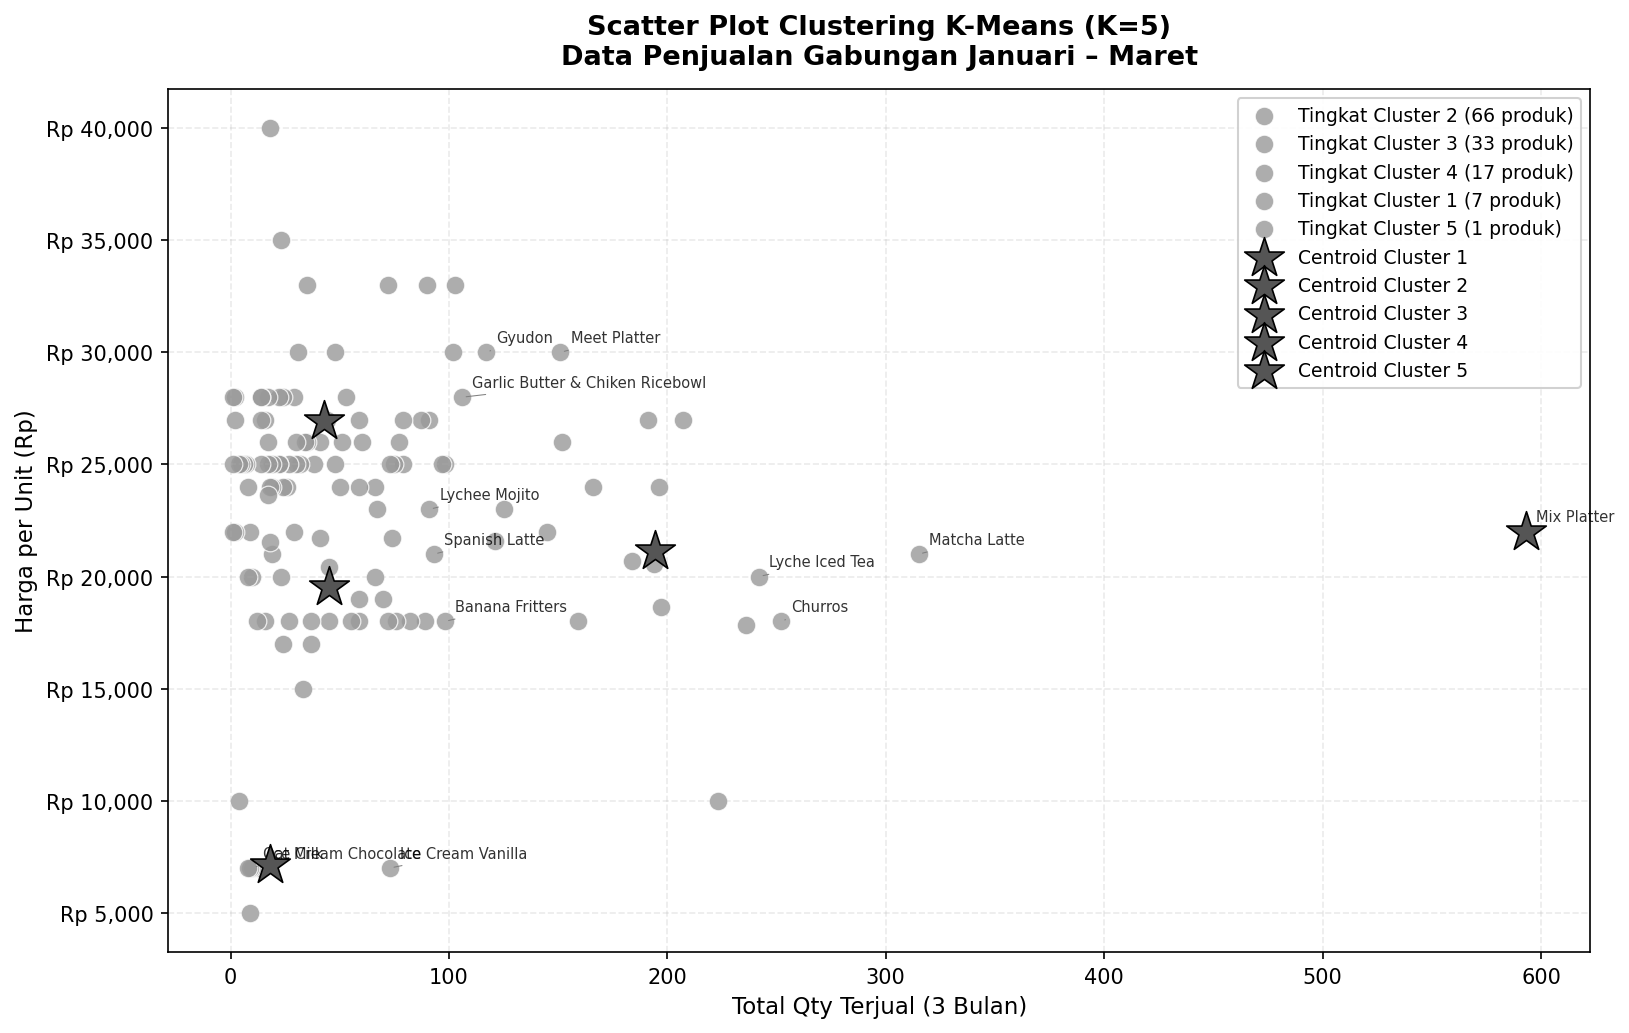


🖼️ 03_TopProduk_Cluster.png:


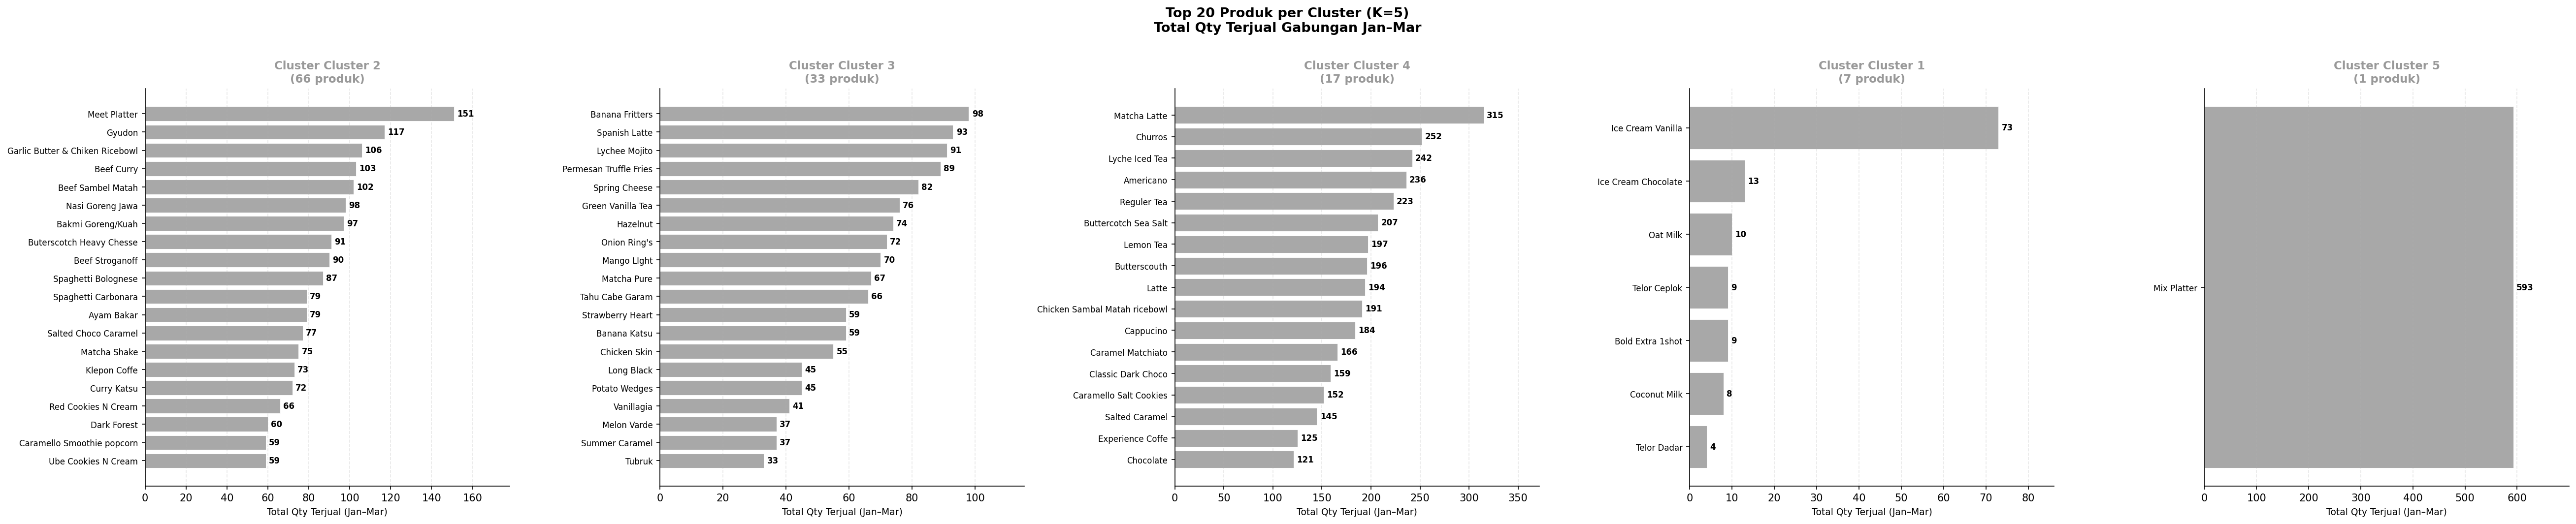


🖼️ 04_Tren_Bulan.png:


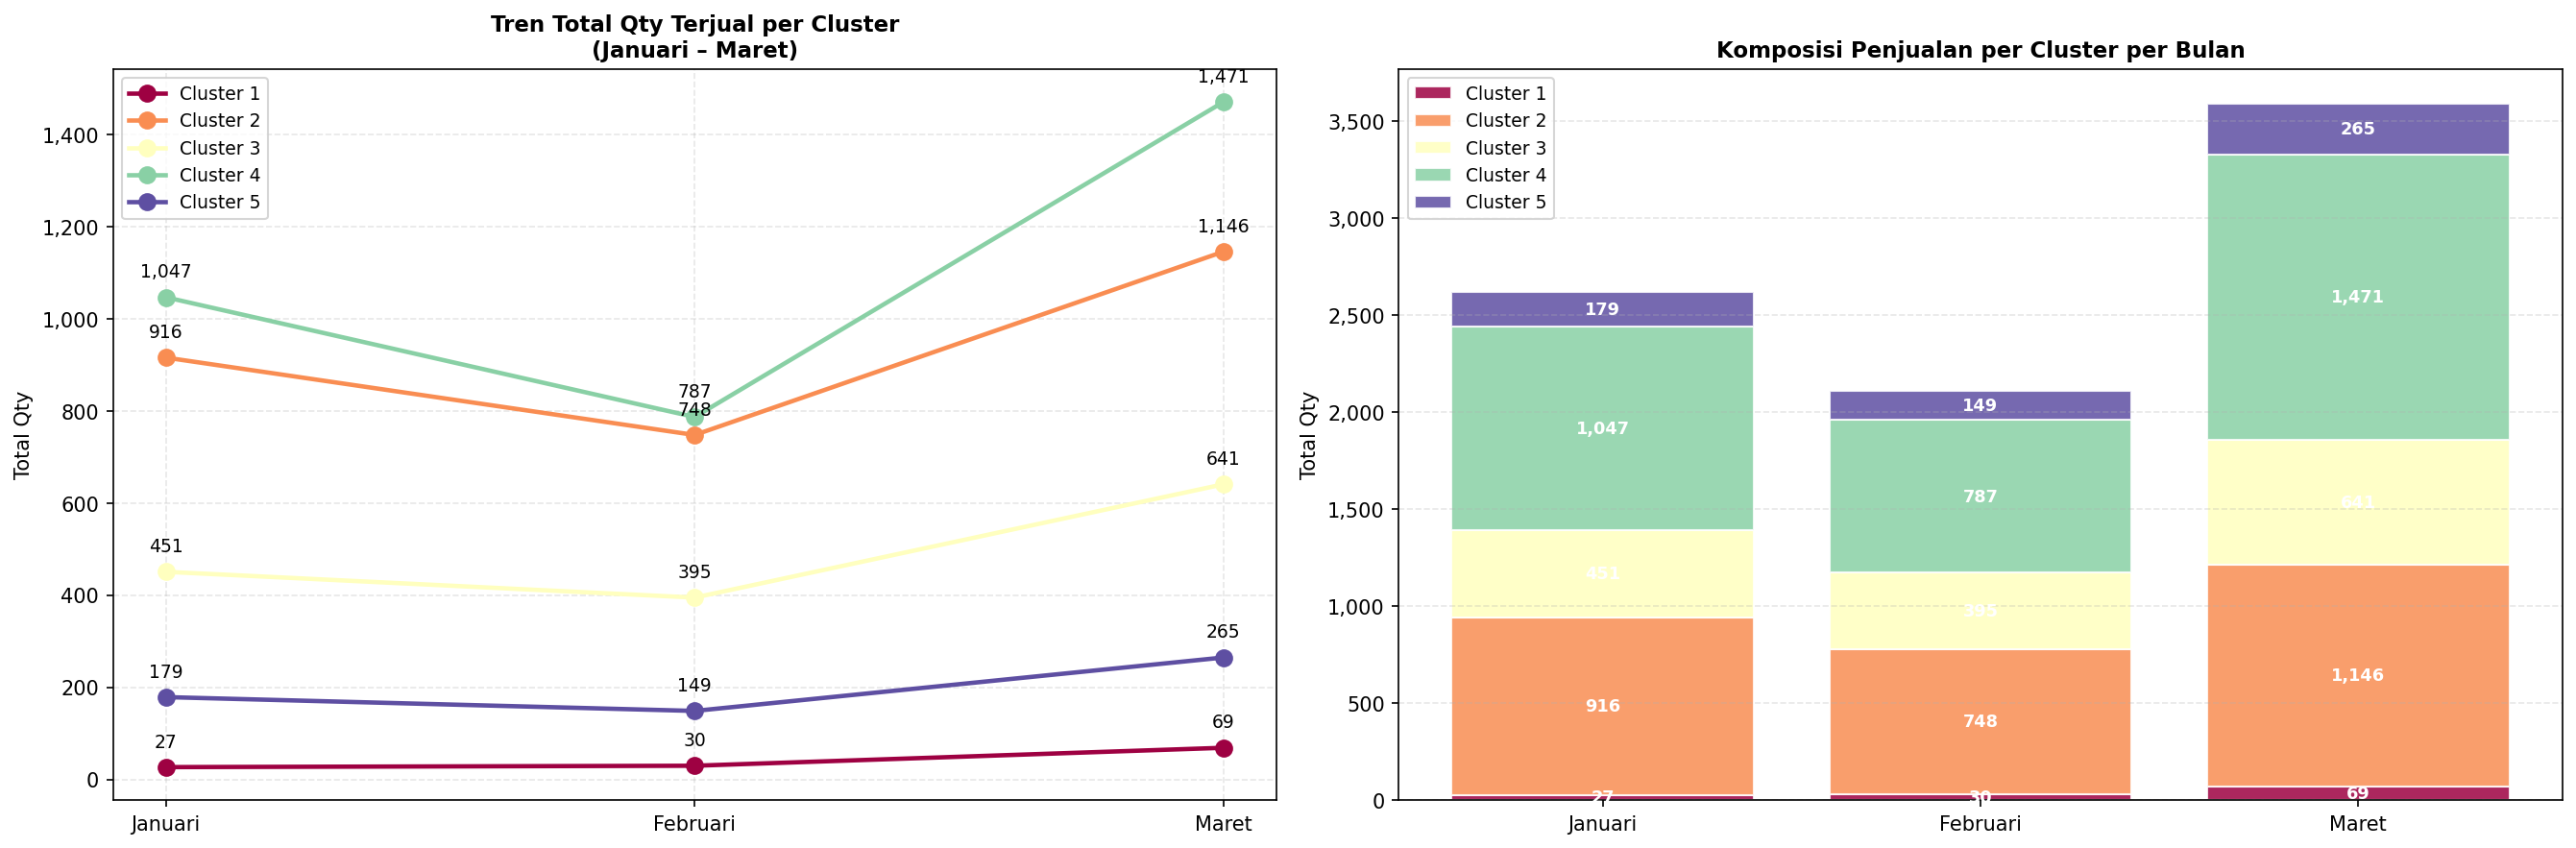


🖼️ 05_Distribusi_Harga.png:


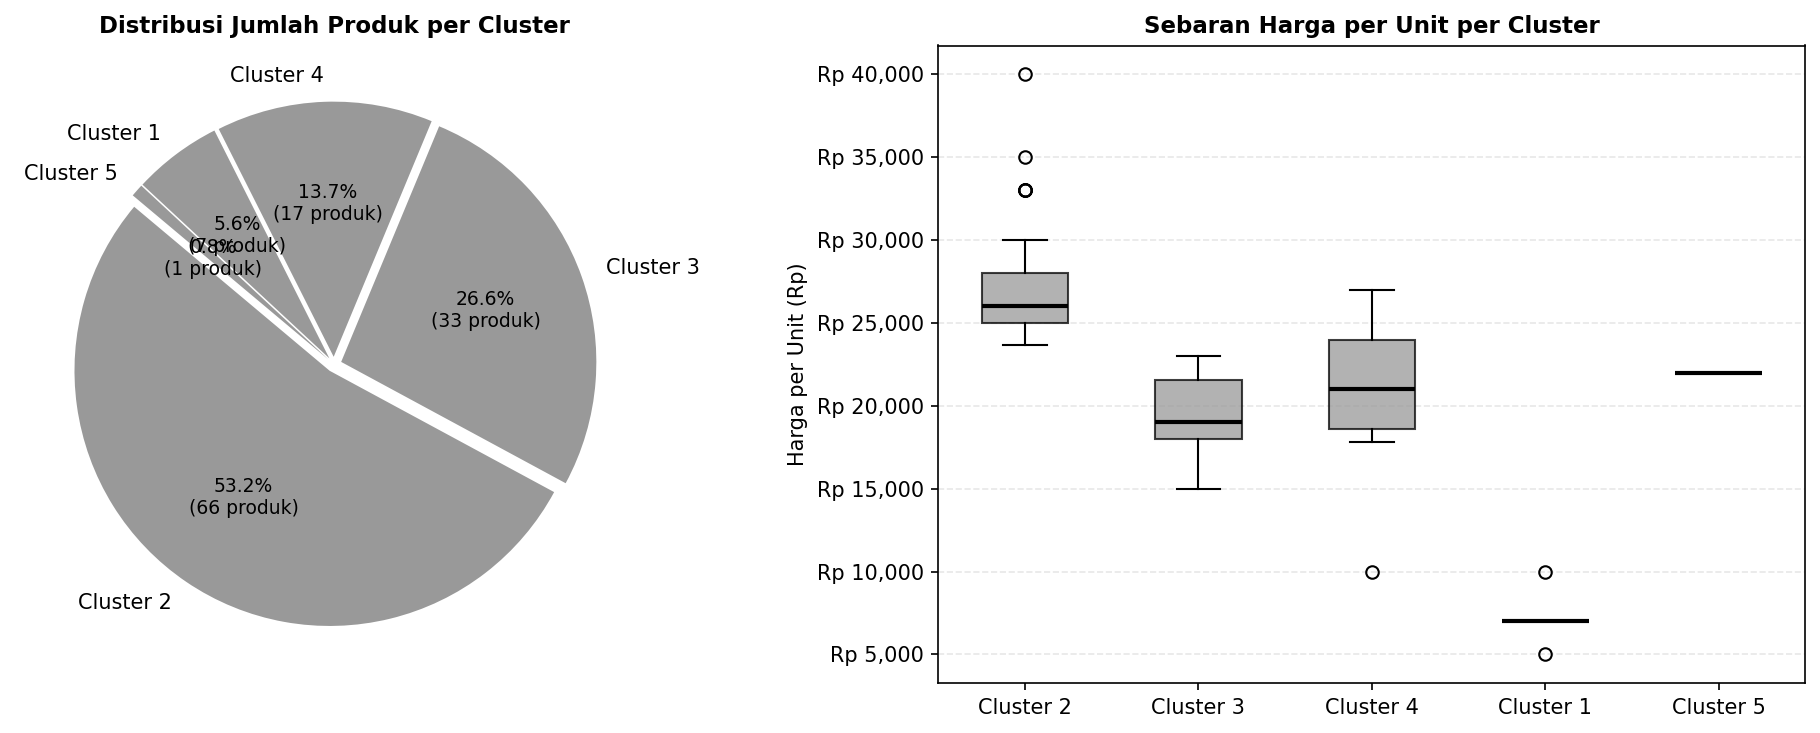


📁 Hasil_Clustering_Gabungan.xlsx (klik untuk mengunduh):


/content/Hasil_Clustering_Gabungan.xlsx

In [38]:
from IPython.display import FileLink, Image, display

output_files = {
    '01_DBI_Evaluasi.png': 'Image',
    '02_Scatter_Cluster.png': 'Image',
    '03_TopProduk_Cluster.png': 'Image',
    '04_Tren_Bulan.png': 'Image',
    '05_Distribusi_Harga.png': 'Image',
    'Hasil_Clustering_Gabungan.xlsx': 'File'
}

print("Berikut adalah hasil analisis Anda:")
for f_name, f_type in output_files.items():
    if f_type == 'Image':
        print(f"\n🖼️ {f_name}:")
        display(Image(filename=f_name))
    elif f_type == 'File':
        print(f"\n📁 {f_name} (klik untuk mengunduh):")
        display(FileLink(f_name))